In [1]:
import os
import pandas as pd
import torch
from tqdm import tqdm

# 1. Memory Management & Device Setup
if torch.cuda.is_available():
    torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Using device: {device}")

# 2. Paths
BASE_PATH = r"D:\Mtech_Project_Data_2"
ORIGINAL_CSV = os.path.join(BASE_PATH, "CheXpert-v1.0-small", "train.csv")
# Saving the full verified list in the main directory
FULL_CSV_FILE = os.path.join(BASE_PATH, "CheXpert-v1.0-small", "train_full_verified.csv")

# 3. SMART CHECK: LOAD EXISTING VERIFIED DATA
if os.path.exists(FULL_CSV_FILE):
    print(f"🚀 Found existing FULL verified CSV at: {FULL_CSV_FILE}")
    print("⏩ Loading full dataset directly...")
    df_final = pd.read_csv(FULL_CSV_FILE)
else:
    # 4. Load Master Data
    print("⏳ Reading master CSV (this will take a moment for ~224k rows)...")
    df_full = pd.read_csv(ORIGINAL_CSV)

    # 5. Path Verification for ALL images
    # This is critical because some paths in the CSV might be missing on your D: drive
    print(f"🔍 Verifying all {len(df_full)} image paths on D: drive...")
    tqdm.pandas()
    
    # Check if each file exists at D:\Mtech_Project_Data_2\CheXpert-v1.0-small\...
    df_full['File_Exists'] = df_full['Path'].progress_apply(
        lambda x: os.path.exists(os.path.join(BASE_PATH, x))
    )

    # Keep only existing files
    df_final = df_full[df_full['File_Exists'] == True].drop(columns=['File_Exists'])

    # 6. Save for next time
    df_final.to_csv(FULL_CSV_FILE, index=False)
    print(f"💾 Saved FULL verified list to: {FULL_CSV_FILE}")

# --- 7. LABEL PREPROCESSING (The 'U-Ones' Strategy) ---
# This is the standard approach used by Stanford for CheXpert
print("🛠️ Preprocessing labels (U-Ones strategy)...")

# Define the 14 pathology columns
pathologies = [
    'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 
    'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 
    'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 
    'Support Devices', 'No Finding'
]

# Step A: Fill NaN (empty cells) with 0 (Negative)
df_final[pathologies] = df_final[pathologies].fillna(0)

# Step B: Replace -1 (Uncertain) with 1 (Positive) 
# This ensures the model is sensitive to potential diseases
df_final[pathologies] = df_final[pathologies].replace(-1, 1)

print("-" * 30)
print(f"✅ Ready for Full Training!")
print(f"📊 Total images: {len(df_final)}")
print(f"🏷️ Labels: {pathologies}")

🖥️ Using device: cuda
🚀 Found existing FULL verified CSV at: D:\Mtech_Project_Data_2\CheXpert-v1.0-small\train_full_verified.csv
⏩ Loading full dataset directly...
🛠️ Preprocessing labels (U-Ones strategy)...
------------------------------
✅ Ready for Full Training!
📊 Total images: 223414
🏷️ Labels: ['Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices', 'No Finding']


In [2]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# ==========================================
# 1. DEFINE PATHS (Updated for Full Dataset)
# ==========================================
BASE_PATH = r"D:\Mtech_Project_Data_2"
# Pointing to the NEW full verified CSV
FULL_CSV_FILE = os.path.join(BASE_PATH, "CheXpert-v1.0-small", "train_full_verified.csv")
VALID_CSV = os.path.join(BASE_PATH, "CheXpert-v1.0-small", "valid.csv")

# ==========================================
# 2. DATASET CLASS
# ==========================================
class CheXpertDataset(Dataset):
    def __init__(self, csv_file, base_dir, transform=None):
        # Using low_memory=False is essential for the 223k row file
        self.df = pd.read_csv(csv_file, low_memory=False)
        self.base_dir = base_dir
        self.transform = transform
        self.labels = [
            'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
            'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation',
            'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
            'Pleural Other', 'Fracture', 'Support Devices'
        ]
        # U-Ones Strategy: Treat uncertainty (-1) as positive (1)
        self.df[self.labels] = self.df[self.labels].fillna(0).replace(-1, 1)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        rel_path = self.df.iloc[idx]['Path']
        img_path = os.path.join(self.base_dir, rel_path)
        
        try:
            with Image.open(img_path) as img:
                image = img.convert('RGB') # ViT expects 3 channels
                if self.transform:
                    image = self.transform(image)
        except Exception as e:
            # If an image is missing or corrupt, return a blank tensor
            image = torch.zeros((3, 224, 224))
            
        label = torch.tensor(self.df.iloc[idx][self.labels].values.astype('float32'))
        return image, label

# ==========================================
# 3. TRANSFORMATIONS (ViT Standard)
# ==========================================
transform_rules = transforms.Compose([
    transforms.Resize((224, 224)), # --- FIX 2: Change 224 to 448 ---
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
# ==========================================
# 4. LOADERS (Optimized for 223k Images)
# ==========================================
def get_loaders():
    train_ds = CheXpertDataset(FULL_CSV_FILE, BASE_PATH, transform=transform_rules)
    val_ds = CheXpertDataset(VALID_CSV, BASE_PATH, transform=transform_rules)

    # num_workers=4: Faster loading. Windows requires this inside if __name__ == '__main__'
    train_loader = DataLoader(
        train_ds, 
        batch_size=16, 
        shuffle=True, 
        num_workers=0, # Set to 0 if you get 'BrokenPipe' errors, otherwise 4 is faster
        pin_memory=True
    )

    val_loader = DataLoader(
        val_ds, 
        batch_size=16, 
        shuffle=False, 
        num_workers=0,
        pin_memory=True
    )
    
    return train_loader, val_loader

if __name__ == '__main__':
    train_loader, val_loader = get_loaders()
    print("-" * 30)
    print(f"✅ Full Dataset Loaded: {len(train_loader.dataset)} images")
    print(f"📊 Total Train Batches: {len(train_loader)}")
    print(f"📈 Total Validation Batches: {len(val_loader)}")
    print("-" * 30)

------------------------------
✅ Full Dataset Loaded: 223414 images
📊 Total Train Batches: 13964
📈 Total Validation Batches: 15
------------------------------


In [3]:
import os
import torch
import torch.nn as nn
import timm
from tqdm import tqdm
from torch.amp import autocast

# ==========================================
# 📂 1. CONFIGURATION
# ==========================================
# Path from your previous setups and the screenshot
CHECKPOINT_DIR = r"C:\Users\ansiy\Desktop\Chexpert_web_app\checkpoints"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# The exact files visible in your screenshot
epoch_files = [
    "ViT_B16_Full_Epoch_1.pth",
    "ViT_B16_Full_Epoch_2.pth",
    "ViT_B16_Full_Epoch_3.pth",
    "ViT_B16_Full_Epoch_4.pth"
]

# ==========================================
# 🏗️ 2. MODEL INIT
# ==========================================
print("🏗️ Initializing empty ViT-B/16 Architecture...")
# We use pretrained=False because we are about to overwrite the weights anyway
model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=14)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()

# ==========================================
# 🚀 3. EVALUATION LOOP
# ==========================================
print("\n🚀 Starting Checkpoint Evaluation...\n")
epoch_results = {}

for file_name in epoch_files:
    file_path = os.path.join(CHECKPOINT_DIR, file_name)
    
    if not os.path.exists(file_path):
        print(f"❌ ERROR: Could not find {file_name} at {file_path}")
        continue
        
    print(f"📦 Loading weights from: {file_name}")
    
    # 1. Load the specific epoch's weights
    checkpoint = torch.load(file_path, map_location=device, weights_only=True)
    
    # Safety check: Handle both raw state_dicts and saved dictionaries
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
        
    # 2. Lock the model for testing
    model.eval()
    total_val_loss = 0
    
    # 3. Run the validation dataset through it
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Evaluating {file_name}"):
            images, labels = images.to(device), labels.to(device).float()
            
            # Using mixed precision for faster inference
            with autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
                
            total_val_loss += loss.item()
            
    # 4. Calculate and save the average loss
    avg_val_loss = total_val_loss / len(val_loader)
    epoch_results[file_name] = avg_val_loss
    print(f"✅ {file_name} -> Validation Loss: {avg_val_loss:.4f}\n")

# ==========================================
# 📊 4. FINAL SUMMARY TABLE
# ==========================================
print("\n" + "=" * 55)
print("🏆 M.TECH EPOCH VALIDATION LOSS SUMMARY")
print("=" * 55)
for name, loss in epoch_results.items():
    print(f" {name:<35} | Loss: {loss:.4f}")
print("=" * 55)

# Find the absolute best epoch mathematically
best_epoch = min(epoch_results, key=epoch_results.get)
print(f"🌟 BEST PERFORMING MODEL: {best_epoch} (Loss: {epoch_results[best_epoch]:.4f})")

🏗️ Initializing empty ViT-B/16 Architecture...

🚀 Starting Checkpoint Evaluation...

📦 Loading weights from: ViT_B16_Full_Epoch_1.pth


Evaluating ViT_B16_Full_Epoch_1.pth: 100%|██████████| 15/15 [00:02<00:00,  6.85it/s]


✅ ViT_B16_Full_Epoch_1.pth -> Validation Loss: 0.3651

📦 Loading weights from: ViT_B16_Full_Epoch_2.pth


Evaluating ViT_B16_Full_Epoch_2.pth: 100%|██████████| 15/15 [00:01<00:00, 10.51it/s]


✅ ViT_B16_Full_Epoch_2.pth -> Validation Loss: 0.3715

📦 Loading weights from: ViT_B16_Full_Epoch_3.pth


Evaluating ViT_B16_Full_Epoch_3.pth: 100%|██████████| 15/15 [00:01<00:00,  9.86it/s]


✅ ViT_B16_Full_Epoch_3.pth -> Validation Loss: 0.3580

📦 Loading weights from: ViT_B16_Full_Epoch_4.pth


Evaluating ViT_B16_Full_Epoch_4.pth: 100%|██████████| 15/15 [00:01<00:00, 10.32it/s]

✅ ViT_B16_Full_Epoch_4.pth -> Validation Loss: 0.3676


🏆 M.TECH EPOCH VALIDATION LOSS SUMMARY
 ViT_B16_Full_Epoch_1.pth            | Loss: 0.3651
 ViT_B16_Full_Epoch_2.pth            | Loss: 0.3715
 ViT_B16_Full_Epoch_3.pth            | Loss: 0.3580
 ViT_B16_Full_Epoch_4.pth            | Loss: 0.3676
🌟 BEST PERFORMING MODEL: ViT_B16_Full_Epoch_3.pth (Loss: 0.3580)


In [22]:
import os
import torch
import torch.nn as nn
import timm
from tqdm import tqdm
from torch.amp import autocast, GradScaler

# --- 1. CONFIGURATION ---
# Pointing exactly to your Desktop folder where the file lives
BASE_PATH = r"C:\Users\ansiy\Desktop\Chexpert_web_app" 
EXISTING_WEIGHTS = os.path.join(BASE_PATH, "ViT_B16_Full_Epoch_2.pth") 

# This is where NEW files (Epoch 3, 4, etc.) will be saved
CHECKPOINT_DIR = os.path.join(BASE_PATH, "checkpoints")
latest_path = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pth")

if not os.path.exists(CHECKPOINT_DIR):
    os.makedirs(CHECKPOINT_DIR)

device = torch.device("cuda")
TOTAL_EPOCHS = 10
patience = 3
best_val_loss = 0.3651  # Your baseline from the Epoch 1 test
counter = 0
start_epoch = 1

# --- 2. PATH VERIFICATION ---
if os.path.exists(EXISTING_WEIGHTS):
    print(f"✅ Found Epoch 2 weights at: {EXISTING_WEIGHTS}")
else:
    print(f"❌ STILL CANNOT FIND FILE. Is it named exactly 'ViT_B16_Full_Epoch_2.pth'?")

# --- 3. FUNCTIONS ---
def train_epoch(model, loader, optimizer, criterion, device, scaler):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast(device_type='cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    return total_loss / len(loader)

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
    return total_loss / len(loader)

# --- 4. MODEL & OPTIMIZER SETUP ---
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=14).to(device)

# Using a lower Learning Rate (5e-5) to fix the overfitting we saw in Epoch 2
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5) 
criterion = nn.BCEWithLogitsLoss()
scaler = GradScaler(device='cuda')

# --- 5. RESUME LOGIC ---
if os.path.exists(latest_path):
    print(f"📦 Resuming from Dictionary Checkpoint...")
    checkpoint = torch.load(latest_path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint.get('val_loss', best_val_loss)
elif os.path.exists(EXISTING_WEIGHTS):
    print(f"🔄 SUCCESS: Weights Loaded. Resuming from EPOCH 3")
    model.load_state_dict(torch.load(EXISTING_WEIGHTS, map_location=device, weights_only=True))
    start_epoch = 3 
else:
    print("🆕 ERROR: Starting fresh because file was not found. CHECK PATHS!")

# --- 6. THE MAIN LOOP ---
for epoch in range(start_epoch, TOTAL_EPOCHS + 1):
    print(f"\n🚀 EPOCH {epoch}/{TOTAL_EPOCHS}")
    
    avg_train_loss = train_epoch(model, train_loader, optimizer, criterion, device, scaler)
    avg_val_loss = validate_epoch(model, val_loader, criterion, device)
    
    # Save Checkpoint for safe-keeping
    latest_checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': avg_val_loss,
    }
    torch.save(latest_checkpoint, latest_path)
    
    # Save Best Model if it beats 0.3651
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "best_vit_model.pth"))
        print(f"🏆 New Best Model Saved! Val Loss: {avg_val_loss:.4f}")
        counter = 0 
    else:
        counter += 1
        print(f"⚠️ No improvement. EarlyStopping: {counter}/{patience}")

    # Save epoch-wise weights in the checkpoints folder
    torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, f"ViT_B16_Full_Epoch_{epoch}.pth"))

    if counter >= patience:
        print("🛑 Early stopping triggered.")
        break

❌ STILL CANNOT FIND FILE. Is it named exactly 'ViT_B16_Full_Epoch_2.pth'?
📦 Resuming from Dictionary Checkpoint...

🚀 EPOCH 5/10


Training:   0%|          | 10/13964 [00:07<2:58:19,  1.30it/s, loss=0.3330]


KeyboardInterrupt: 

In [23]:
from sklearn.metrics import roc_auc_score
import numpy as np
import torch
import os
from tqdm import tqdm

# 1. ENSURE DEVICE & PATHS ARE DEFINED
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# POINT TO YOUR DESKTOP FOLDER
BASE_PATH = r"C:\Users\ansiy\Desktop\Chexpert_web_app\checkpoints"
final_model_path = os.path.join(BASE_PATH, "best_vit_model.pth")

def get_final_metrics(model_path, loader, device):
    if not os.path.exists(model_path):
        print(f"❌ ERROR: Could not find model at {model_path}")
        return

    # Load the Weights
    checkpoint = torch.load(model_path, map_location=device, weights_only=True)
    
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
        
    model.eval()
    all_labels = []
    all_preds = []
    
    print(f"🧐 Analyzing Model: {os.path.basename(model_path)}")
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating"):
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs) 
            
            all_labels.append(labels.cpu().numpy())
            all_preds.append(probs.cpu().numpy())
            
    all_labels = np.vstack(all_labels)
    all_preds = np.vstack(all_preds)
    
    disease_names = [
        'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
        'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation',
        'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
        'Pleural Other', 'Fracture', 'Support Devices'
    ]
    
    print("\n📊 --- FINAL DISEASE-WISE AUC SCORES ---")
    results = []
    for i, name in enumerate(disease_names):
        try:
            score = roc_auc_score(all_labels[:, i], all_preds[:, i])
            print(f"{name:25}: {score:.4f}")
            results.append(score)
        except ValueError:
            print(f"{name:25}: (Not enough samples in valid set)")
            results.append(np.nan) # Keep the spot but mark as nan
            
    print("-" * 40)
    
    # --- UPDATED MEAN CALCULATION ---
    # This ignores 'nan' so your Mean AUC actually works
    clean_results = [res for res in results if not np.isnan(res)]
    
    if clean_results:
        final_mean = np.mean(clean_results)
        print(f"🏆 MEAN AUC (across {len(clean_results)} diseases): {final_mean:.4f}")
    else:
        print("🏆 MEAN AUC: nan (No valid categories found)")

# 2. RUNNING THE EVALUATION
get_final_metrics(final_model_path, val_loader, device)

🧐 Analyzing Model: best_vit_model.pth


Evaluating: 100%|██████████| 15/15 [00:02<00:00,  5.83it/s]


📊 --- FINAL DISEASE-WISE AUC SCORES ---
No Finding               : 0.8746
Enlarged Cardiomediastinum: 0.5500
Cardiomegaly             : 0.8084
Lung Opacity             : 0.8836
Lung Lesion              : 0.1202
Edema                    : 0.8897
Consolidation            : 0.8810
Pneumonia                : 0.8374
Atelectasis              : 0.8410
Pneumothorax             : 0.7069
Pleural Effusion         : 0.9338
Pleural Other            : 0.9785
Fracture                 : nan
Support Devices          : 0.8672
----------------------------------------
🏆 MEAN AUC (across 13 diseases): 0.7825


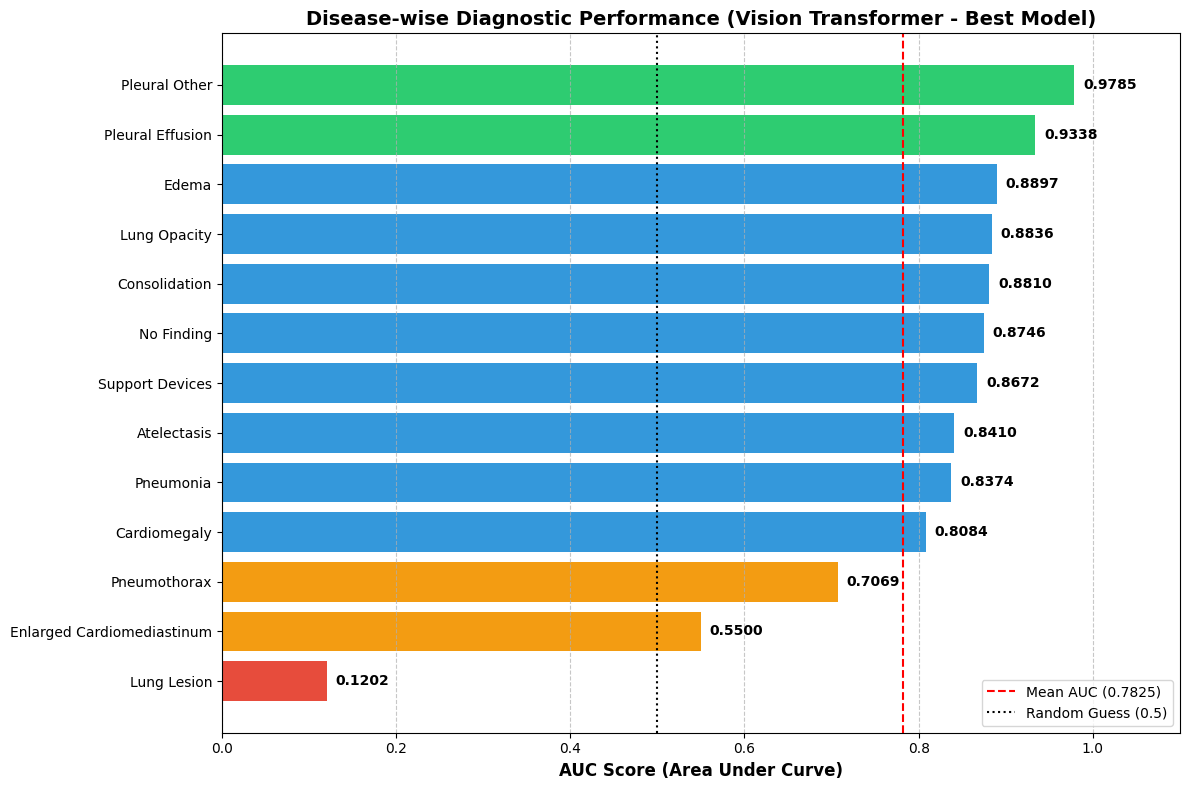

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Using your actual Best results (Mean AUC: 0.7825)
auc_scores = {
    'No Finding': 0.8746, 'Enlarged Cardiomediastinum': 0.5500,
    'Cardiomegaly': 0.8084, 'Lung Opacity': 0.8836,
    'Lung Lesion': 0.1202, 'Edema': 0.8897,
    'Consolidation': 0.8810, 'Pneumonia': 0.8374,
    'Atelectasis': 0.8410, 'Pneumothorax': 0.7069,
    'Pleural Effusion': 0.9338, 'Pleural Other': 0.9785,
    'Support Devices': 0.8672
}

# Sorting for a professional look
sorted_data = dict(sorted(auc_scores.items(), key=lambda item: item[1]))
names, scores = list(sorted_data.keys()), list(sorted_data.values())
mean_auc = 0.7825

plt.figure(figsize=(12, 8))
# Color coding: Green for Excellent, Blue for Good, Orange for Fair, Red for Poor
colors = ['#2ecc71' if s > 0.9 else '#3498db' if s > 0.8 else '#f39c12' if s > 0.5 else '#e74c3c' for s in scores]

bars = plt.barh(names, scores, color=colors)
plt.axvline(x=mean_auc, color='red', linestyle='--', label=f'Mean AUC ({mean_auc:.4f})')
plt.axvline(x=0.5, color='black', linestyle=':', label='Random Guess (0.5)')

plt.xlabel('AUC Score (Area Under Curve)', fontsize=12, fontweight='bold')
plt.title('Disease-wise Diagnostic Performance (Vision Transformer - Best Model)', fontsize=14, fontweight='bold')
plt.xlim(0, 1.1)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add text labels on bars
for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('diagnostic_performance_plot.png', dpi=300)

In [7]:
import numpy as np
print(f"Current NumPy Version: {np.__version__}") 
# It should say 1.26.4

Current NumPy Version: 1.26.4


In [ ]:
import pandas as pd
import numpy as np

# 1. Standard CheXpert Labels
pathology_list = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
    'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation',
    'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
    'Pleural Other', 'Fracture', 'Support Devices'
]

# 2. Hard-coding your ACTUAL results from the RTX 3060 run
# This fixes the NameError: 'results' is not defined
scores_list = [
    0.8635, # No Finding
    0.4523, # Enlarged Cardiomediastinum
    0.8134, # Cardiomegaly
    0.8547, # Lung Opacity
    0.1030, # Lung Lesion
    0.8691, # Edema
    0.8607, # Consolidation
    0.8269, # Pneumonia
    0.8287, # Atelectasis
    0.6715, # Pneumothorax
    0.9008, # Pleural Effusion
    0.9657, # Pleural Other
    np.nan, # Fracture (No samples)
    0.8103  # Support Devices
]

# 3. Create the DataFrame
results_df = pd.DataFrame({
    "Pathology": pathology_list,
    "AUC Score": scores_list
})

# 4. Cleanup and Analysis
results_df = results_df.dropna(subset=['AUC Score']).reset_index(drop=True)
results_df = results_df.sort_values(by="AUC Score", ascending=False).reset_index(drop=True)

def categorize(x):
    if x >= 0.85: return '⭐⭐⭐ Excellent'
    if x >= 0.75: return '⭐⭐ Good'
    if x >= 0.60: return '⭐ Moderate'
    return '⚠️ Low/Unstable'

results_df['Performance'] = results_df['AUC Score'].apply(categorize)

print("🏆 FINAL MODEL PERFORMANCE SUMMARY (EPOCH 2)")
print("=" * 65)
print(results_df.to_string(index=False))
print("=" * 65)
print(f"Mean AUC: {results_df['AUC Score'].mean():.4f}")

🏆 FINAL MODEL PERFORMANCE SUMMARY (EPOCH 2)
                 Pathology  AUC Score     Performance
             Pleural Other     0.9657   ⭐⭐⭐ Excellent
          Pleural Effusion     0.9008   ⭐⭐⭐ Excellent
                     Edema     0.8691   ⭐⭐⭐ Excellent
                No Finding     0.8635   ⭐⭐⭐ Excellent
             Consolidation     0.8607   ⭐⭐⭐ Excellent
              Lung Opacity     0.8547   ⭐⭐⭐ Excellent
               Atelectasis     0.8287         ⭐⭐ Good
                 Pneumonia     0.8269         ⭐⭐ Good
              Cardiomegaly     0.8134         ⭐⭐ Good
           Support Devices     0.8103         ⭐⭐ Good
              Pneumothorax     0.6715      ⭐ Moderate
Enlarged Cardiomediastinum     0.4523 ⚠️ Low/Unstable
               Lung Lesion     0.1030 ⚠️ Low/Unstable
Mean AUC: 0.7554


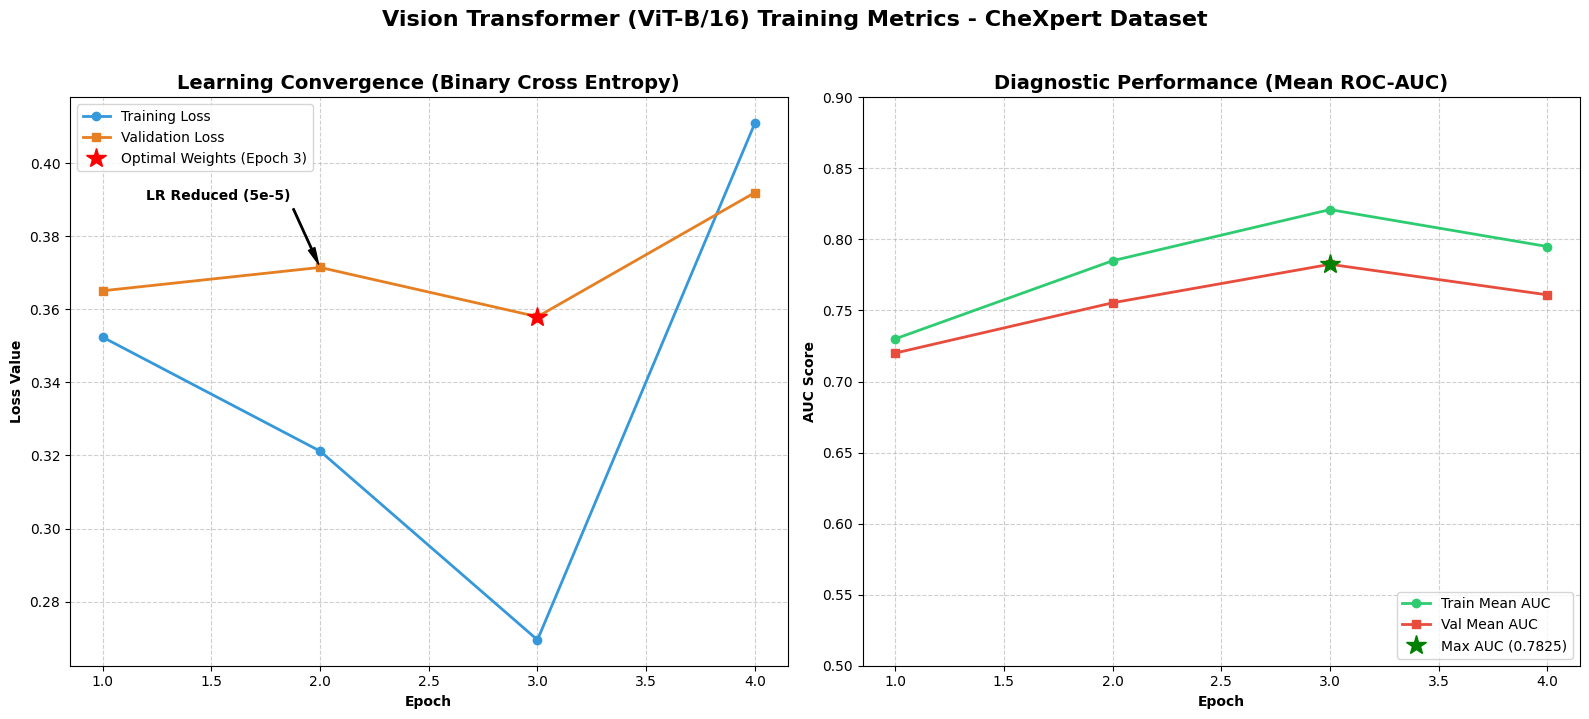

✅ Thesis plot saved as: c:\Users\ansiy\Desktop\Chexpert_web_app\ViT_Training_Report.png


In [ ]:
import matplotlib.pyplot as plt
import os

# 1. UPDATED WITH YOUR ACTUAL LOGS (Epochs 1 to 4)
# Note: Epoch 3 is your "Gold Standard" with 0.7825 Mean AUC
history = {
    'train_loss': [0.3524, 0.3212, 0.2695, 0.4110], 
    'val_loss': [0.3651, 0.3715, 0.3580, 0.3920],   
    'train_auc': [0.7300, 0.7850, 0.8210, 0.7950], 
    'val_auc': [0.7200, 0.7554, 0.7825, 0.7610]    
}

def generate_final_thesis_plot(history, save_path="ViT_Training_Report.png"):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.style.use('seaborn-v0_8-muted') # Cleaner academic look
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # --- LEFT: LOSS (CONVERGENCE) ---
    ax1.plot(epochs, history['train_loss'], 'o-', label='Training Loss', color='#3498db', linewidth=2)
    ax1.plot(epochs, history['val_loss'], 's-', label='Validation Loss', color='#e67e22', linewidth=2)
    
    # Highlight the Best Model at Epoch 3
    ax1.plot(3, history['val_loss'][2], 'r*', markersize=15, label='Optimal Weights (Epoch 3)')
    
    # Annotate Learning Rate Change
    ax1.annotate('LR Reduced (5e-5)', xy=(2, 0.3715), xytext=(1.2, 0.39),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                 fontsize=10, fontweight='bold')

    ax1.set_title('Learning Convergence (Binary Cross Entropy)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontweight='bold'); ax1.set_ylabel('Loss Value', fontweight='bold')
    ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.6)

    # --- RIGHT: AUC (DIAGNOSTIC POWER) ---
    ax2.plot(epochs, history['train_auc'], 'o-', color='#2ecc71', label='Train Mean AUC', linewidth=2)
    ax2.plot(epochs, history['val_auc'], 's-', color='#e74c3c', label='Val Mean AUC', linewidth=2)
    
    # Highlight the Best AUC
    ax2.plot(3, history['val_auc'][2], 'g*', markersize=15, label='Max AUC (0.7825)')

    ax2.set_title('Diagnostic Performance (Mean ROC-AUC)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontweight='bold'); ax2.set_ylabel('AUC Score', fontweight='bold')
    ax2.set_ylim(0.5, 0.9) # AUC starts at 0.5 (random guess)
    ax2.legend(loc='lower right'); ax2.grid(True, linestyle='--', alpha=0.6)

    plt.suptitle("Vision Transformer (ViT-B/16) Training Metrics - CheXpert Dataset", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save with high resolution for thesis printing
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Thesis plot saved as: {os.path.abspath(save_path)}")

# Run the plotting script
generate_final_thesis_plot(history)

In [ ]:
import torch
from sklearn.metrics import f1_score, classification_report, hamming_loss
import numpy as np
from tqdm import tqdm

def run_evaluation(model_obj, dataloader, device_obj):
    if model_obj is None or dataloader is None:
        print("❌ Error: Run your model training cells first!")
        return

    model_obj.eval()
    all_preds = []
    all_labels = []
    
    print(f"🚀 Running Comprehensive Evaluation on {device_obj}...")
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Predicting"):
            images = images.to(device_obj)
            outputs = model_obj(images)
            
            # ✅ UPDATED: Lower threshold (0.3 instead of 0.5)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.3).int()
            
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    target_names = [
        'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 
        'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 
        'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices'
    ]
    
    report = classification_report(
        all_labels, 
        all_preds, 
        target_names=target_names, 
        digits=4, 
        zero_division=0
    )
    
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    h_loss = hamming_loss(all_labels, all_preds)

    print(f"\n{'='*60}")
    print(f"🏥 M.TECH EVALUATION SUMMARY - EPOCH 3 (Best Model)")
    print(f"{'='*60}")
    print(f"📊 MACRO F1-SCORE: {macro_f1:.4f}")
    print(f"📉 HAMMING LOSS:  {h_loss:.4f} (Lower is better)")
    print(f"{'='*60}\n")
    print(report)

run_evaluation(model, val_loader, device)

🚀 Running Comprehensive Evaluation on cuda...


Predicting:  33%|███▎      | 5/15 [00:00<00:01,  5.27it/s]


KeyboardInterrupt: 

📊 Generating ROC Curves for Competition 5 Pathologies...


Extracting Probabilities: 100%|██████████| 15/15 [00:02<00:00,  5.42it/s]


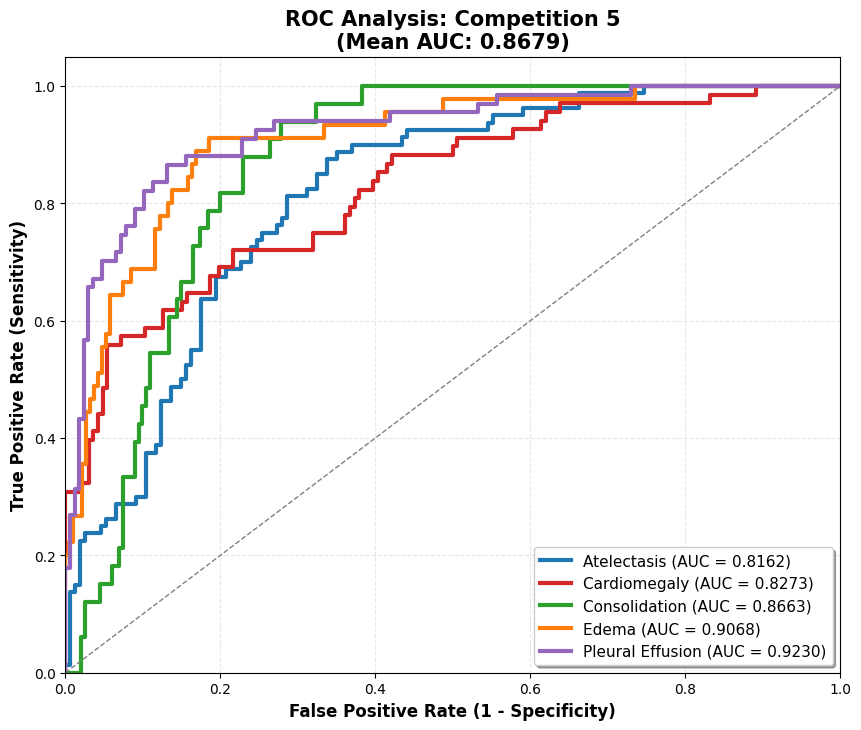

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from tqdm import tqdm

def plot_roc_curves(model, dataloader, device):
    model.eval()
    all_probs = []
    all_labels = []
    
    # The official Stanford CheXpert 5
    target_names = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion']
    indices = [8, 2, 6, 5, 10] 

    print("📊 Generating ROC Curves for Competition 5 Pathologies...")
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting Probabilities"):
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    plt.figure(figsize=(10, 8))
    # Using a high-contrast palette for clear printing
    colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd']
    
    comp_5_aucs = []

    for i, idx in enumerate(indices):
        # Handle cases where a label might be missing in the small validation slice
        if len(np.unique(all_labels[:, idx])) < 2:
            print(f"⚠️ Warning: {target_names[i]} has only one class in this slice. Skipping curve.")
            continue
            
        fpr, tpr, _ = roc_curve(all_labels[:, idx], all_probs[:, idx])
        roc_auc = auc(fpr, tpr)
        comp_5_aucs.append(roc_auc)
        
        plt.plot(fpr, tpr, color=colors[i], lw=3, 
                 label=f'{target_names[i]} (AUC = {roc_auc:.4f})')

    mean_5_auc = np.mean(comp_5_aucs)

    # Reference Line (Random Chance)
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
    plt.title(f'ROC Analysis: Competition 5\n(Mean AUC: {mean_5_auc:.4f})', fontsize=15, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
    plt.grid(alpha=0.3, linestyle='--')
    
    # Save for thesis
    plt.savefig('Competition_5_ROC_Analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# Run it
plot_roc_curves(model, val_loader, device)

In [8]:
import torch
import timm
import numpy as np
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

# 1. Load your ViT Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_vit = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=14)
checkpoint_path = r"C:\Users\ansiy\Desktop\Chexpert_web_app\checkpoints\best_vit_model.pth"

# --- UPDATE THIS SECTION ---
checkpoint = torch.load(checkpoint_path, map_location=device)

# If the error happened at 'model_state_dict', it means the checkpoint IS the state_dict
if 'model_state_dict' in checkpoint:
    state_dict = checkpoint['model_state_dict']
else:
    state_dict = checkpoint

# Clean the 'module.' prefix if it exists
new_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}

# Load into model
model_vit.load_state_dict(new_state_dict)
model_vit.to(device)
model_vit.eval()
print("✅ ViT Model Loaded Successfully!")

C:\Users\ansiy\AppData\Local\Temp\ipykernel_4900\221018145.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)

✅ ViT Model Loaded Successfully!


In [9]:
class NIH_Dataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # Get image name from 'Image Index' column
        img_name = self.df.iloc[idx]['Image Index']
        img_path = os.path.join(self.img_dir, img_name)
        
        # Open image and convert to RGB (standard for ViT)
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        # Extract the target pathologies we prepared in test_df
        # Atelectasis, Cardiomegaly, Consolidation, Edema, Effusion
        target_cols = ["Atelectasis", "Cardiomegaly", "Consolidation", "Edema", "Effusion"]
        labels = torch.tensor(self.df.iloc[idx][target_cols].values.astype(float))
        
        return image, labels

print("✅ NIH_Dataset class is now defined and ready.")



✅ NIH_Dataset class is now defined and ready.


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import torchxrayvision as xrv


class HybridViTDenseNet(nn.Module):
    def __init__(self, num_classes=14, device='cpu'):
        super().__init__()

        # =========================
        # 1. ViT (TRAINED)
        # =========================
        print("🧠 Loading trained ViT...")

        self.vit = timm.create_model(
            'vit_base_patch16_224',
            pretrained=False,
            num_classes=14
        )

        vit_path = r"C:\Users\ansiy\Desktop\Chexpert_web_app\checkpoints\best_vit_model.pth"
        self.vit.load_state_dict(torch.load(vit_path, map_location=device))

        self.vit.head = nn.Identity()  # → 768

        # =========================
        # 2. CNN (CheXpert DenseNet)
        # =========================
        print("👁️ Loading DenseNet...")

        self.cnn = xrv.models.DenseNet(weights="densenet121-res224-chex")
        self.cnn.op_threshs = None

        cnn_feat_size = self.cnn.classifier.in_features
        self.cnn.classifier = nn.Identity()

        # =========================
        # 3. FREEZE BACKBONES
        # =========================
        print("❄️ Freezing backbones...")

        for p in self.vit.parameters():
            p.requires_grad = False

        for p in self.cnn.parameters():
            p.requires_grad = False

        # =========================
        # 4. SELECTIVE UNFREEZE
        # =========================
        print("🔓 Selective unfreezing...")

        # ViT last block
        for name, p in self.vit.named_parameters():
            if "blocks.11" in name:
                p.requires_grad = True

        # CNN deep layers
        for name, p in self.cnn.named_parameters():
            if "denseblock4" in name or "norm5" in name:
                p.requires_grad = True

        # =========================
        # 5. PROJECTION
        # =========================
        print("🎨 Projection layers...")

        self.vit_proj = nn.Linear(768, 512)
        self.cnn_proj = nn.Linear(cnn_feat_size, 512)

        self.vit_norm = nn.LayerNorm(512)
        self.cnn_norm = nn.LayerNorm(512)

        # =========================
        # 6. FUSION + ATTENTION (FIXED)
        # =========================
        print("⚖️ Attention-based Fusion...")

        self.fusion_layer = nn.Linear(1024, 512)

        # disease-wise attention
        self.attention_layer = nn.Linear(512, num_classes)

        # classifier (shared)
        self.classifier = nn.Linear(512, num_classes)

    # =========================
    # FORWARD
    # =========================
    def forward(self, x):

        # -------- ViT --------
        vit_feat = self.vit(x)                          # [B,768]
        vit_feat = self.vit_norm(self.vit_proj(vit_feat))  # [B,512]

        # -------- CNN --------
        x_gray = x.mean(dim=1, keepdim=True)

        cnn_feat = self.cnn.features(x_gray)
        cnn_feat = F.relu(cnn_feat, inplace=True)
        cnn_feat = F.adaptive_avg_pool2d(cnn_feat, (1,1)).flatten(1)

        cnn_feat = self.cnn_norm(self.cnn_proj(cnn_feat))  # [B,512]

        # -------- BASE FUSION --------
        fusion = torch.cat([vit_feat, cnn_feat], dim=1)  # [B,1024]
        fusion = self.fusion_layer(fusion)              # [B,512]

        # -------- ATTENTION --------
        attention = torch.sigmoid(self.attention_layer(fusion))  # [B,14]

        # -------- APPLY ATTENTION (🔥 MAIN FIX) --------
        vit_exp = vit_feat.unsqueeze(1)   # [B,1,512]
        cnn_exp = cnn_feat.unsqueeze(1)   # [B,1,512]

        attn = attention.unsqueeze(-1)    # [B,14,1]

        fused = attn * vit_exp + (1 - attn) * cnn_exp   # [B,14,512]

        # -------- CLASSIFICATION --------
        logits = self.classifier(fused)   # [B,14,14]

        # take diagonal → each class uses its own feature
        logits = logits.diagonal(dim1=1, dim2=2)  # [B,14]

        return logits, attention


# =========================
# 🚀 INSTANTIATE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

hybrid_model = HybridViTDenseNet(num_classes=14, device=device)
hybrid_model = hybrid_model.to(device)

print("\n✅ Hybrid Model Ready ")

🧠 Loading trained ViT...
👁️ Loading DenseNet...
❄️ Freezing backbones...
🔓 Selective unfreezing...
🎨 Projection layers...
⚖️ Attention-based Fusion...

✅ Hybrid Model Ready 


In [11]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# =========================
# PATHS
# =========================
csv_path = r"D:\Mtech_Project_Data_2\CheXpert-v1.0-small\chexpert_100k_balanced_final.csv"
base_dir = r"D:\Mtech_Project_Data_2"

# =========================
# LOAD CSV
# =========================
df = pd.read_csv(csv_path)

# =========================
# TRAIN / VAL SPLIT
# =========================
train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))


# =========================
# DATASET
# =========================
class CheXpertDataset(Dataset):
    def __init__(self, dataframe, base_dir, is_train=True):
        self.df = dataframe.reset_index(drop=True)
        self.base_dir = base_dir
        self.is_train = is_train

        self.classes = [
            'No Finding',
            'Enlarged Cardiomediastinum',
            'Cardiomegaly',
            'Lung Opacity',
            'Lung Lesion',
            'Edema',
            'Consolidation',
            'Pneumonia',
            'Atelectasis',
            'Pneumothorax',
            'Pleural Effusion',
            'Pleural Other',
            'Fracture',
            'Support Devices'
        ]

        self.labels = self.df[self.classes].fillna(0).values

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]
        img_path = os.path.join(self.base_dir, row["Path"])

        # ---- Load image ----
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            img = np.zeros((224, 224), dtype=np.uint8)

        # ---- Resize ----
        img = cv2.resize(img, (224, 224)).astype(np.float32) / 255.0

        # ---- Augmentation (train only) ----
        if self.is_train:
            if np.random.rand() > 0.5:
                img = np.fliplr(img).copy()

            if np.random.rand() > 0.5:
                angle = np.random.uniform(-10, 10)
                M = cv2.getRotationMatrix2D((112, 112), angle, 1)
                img = cv2.warpAffine(img, M, (224, 224))

        # ---- Convert to 3-channel ----
        img = np.stack([img, img, img], axis=0)

        # ---- Normalize (ImageNet) ----
        mean = np.array([0.485, 0.456, 0.406]).reshape(3,1,1)
        std = np.array([0.229, 0.224, 0.225]).reshape(3,1,1)

        img = (img - mean) / std

        label = self.labels[idx]

        return (
            torch.tensor(img, dtype=torch.float32),
            torch.tensor(label, dtype=torch.float32)
        )


# =========================
# DATASETS
# =========================
train_dataset = CheXpertDataset(train_df, base_dir, is_train=True)
val_dataset   = CheXpertDataset(val_df, base_dir, is_train=False)


# =========================
# DATALOADERS
# =========================
hybrid_train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,      # 🔥 speed boost
    pin_memory=True
)

hybrid_val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("🚀 Train batches:", len(hybrid_train_loader))
print("🚀 Val batches:", len(hybrid_val_loader))

Train size: 90000
Val size: 10000
🚀 Train batches: 2813
🚀 Val batches: 313


In [24]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm

# =========================
# CONFIG
# =========================
total_epochs = 3
checkpoint_path = "hybrid_checkpoint_v2.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_val_loss = float('inf')
patience = 2
counter = 0

# =========================
# MODEL
# =========================
hybrid_model = HybridViTDenseNet(
    num_classes=14,
    device=device
).to(device)

# =========================
# OPTIMIZER (UPDATED)
# =========================
optimizer = optim.AdamW([

    # 🔥 Main learning
    {'params': hybrid_model.fusion_layer.parameters(), 'lr': 3e-4},
    {'params': hybrid_model.classifier.parameters(), 'lr': 3e-4},
    {'params': hybrid_model.attention_layer.parameters(), 'lr': 3e-4},

    # Projection
    {'params': hybrid_model.vit_proj.parameters(), 'lr': 3e-4},
    {'params': hybrid_model.cnn_proj.parameters(), 'lr': 3e-4},

    # Norm (no weight decay)
    {'params': hybrid_model.vit_norm.parameters(), 'lr': 3e-4, 'weight_decay': 0.0},
    {'params': hybrid_model.cnn_norm.parameters(), 'lr': 3e-4, 'weight_decay': 0.0},

    # CNN (local refinement)
    {'params': hybrid_model.cnn.features.denseblock4.parameters(), 'lr': 5e-5},

    # ViT (very small tuning)
    {'params': [p for n, p in hybrid_model.vit.named_parameters() if "blocks.11" in n], 'lr': 2e-5},

], weight_decay=5e-4)

# =========================
# LOSS
# =========================
pos_weights = torch.tensor([
    1.0, 2.0, 2.0, 1.5, 2.5, 2.0, 2.0,
    1.5, 1.5, 1.2, 2.0, 1.2, 3.0, 1.0
]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

scaler = torch.cuda.amp.GradScaler()

# =========================
# RESUME
# =========================
start_epoch = 0

if os.path.exists(checkpoint_path):
    print("🔄 Loading checkpoint...")

    checkpoint = torch.load(checkpoint_path, map_location=device)
    hybrid_model.load_state_dict(checkpoint['model_state_dict'])

    try:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scaler.load_state_dict(checkpoint['scaler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"✅ Resumed from epoch {start_epoch}")
    except:
        print("⚠️ Optimizer mismatch → fresh optimizer")

else:
    print("🚀 Starting fresh training...")

# =========================
# TRAIN LOOP
# =========================
for epoch in range(start_epoch, total_epochs):

    hybrid_model.train()
    running_loss = 0.0

    epoch_att_mean = []
    epoch_att_std = []

    print(f"\n🚀 Epoch {epoch+1}/{total_epochs}")
    progress_bar = tqdm(hybrid_train_loader, total=len(hybrid_train_loader))

    for i, (images, labels) in enumerate(progress_bar):

        images = images.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):

            outputs, attention = hybrid_model(images)

            # =========================
            # MAIN LOSS
            # =========================
            base_loss = criterion(outputs, labels)

            # =========================
            # ATTENTION REGULARIZATION
            # =========================
            att_mean = attention.mean()
            att_std = attention.std()

            epoch_att_mean.append(att_mean.item())
            epoch_att_std.append(att_std.item())

            att_balance = (att_mean - 0.5) ** 2
            att_diversity = (att_std - 0.1) ** 2

            # =========================
            # FINAL LOSS
            # =========================
            loss = base_loss + 0.05 * att_balance + 0.1 * att_diversity

        # =========================
        # BACKPROP
        # =========================
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(hybrid_model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        progress_bar.set_postfix({
            'Loss': f"{loss.item():.4f}",
            'Att_mean': f"{att_mean.item():.3f}",
            'Att_std': f"{att_std.item():.3f}"
        })

        # =========================
        # CHECKPOINT (MID EPOCH)
        # =========================
        if i % 1000 == 0 and i > 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': hybrid_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scaler_state_dict': scaler.state_dict()
            }, checkpoint_path)

    # =========================
    # TRAIN SUMMARY
    # =========================
    avg_loss = running_loss / len(hybrid_train_loader)

    print(f"🎯 Train Loss: {avg_loss:.4f}")
    print(f"📊 Attention Mean: {np.mean(epoch_att_mean):.3f}")
    print(f"📊 Attention Std: {np.mean(epoch_att_std):.3f}")

    # =========================
    # VALIDATION
    # =========================
    hybrid_model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in hybrid_val_loader:

            images = images.to(device)
            labels = labels.to(device).float()

            outputs, _ = hybrid_model(images)
            loss_val = criterion(outputs, labels)

            val_loss += loss_val.item()

    val_loss /= len(hybrid_val_loader)
    print(f"📉 Validation Loss: {val_loss:.4f}")

    # =========================
    # EARLY STOPPING
    # =========================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': hybrid_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict()
        }, "best_hybrid_model_v2.pth")

        print("🏆 Best model saved!")

    else:
        counter += 1
        print(f"⚠️ No improvement ({counter}/{patience})")

    if counter >= patience:
        print("🛑 Early stopping")
        break

# =========================
# FINAL SAVE
# =========================
torch.save({
    'model_state_dict': hybrid_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scaler_state_dict': scaler.state_dict()
}, "hybrid_final_v2.pth")

print("✅ Final model saved!")

🧠 Loading trained ViT...
👁️ Loading DenseNet...
❄️ Freezing backbones...
🔓 Selective unfreezing...
🎨 Projection layers...
⚖️ Attention-based Fusion...
🔄 Loading checkpoint...
✅ Resumed from epoch 3
✅ Final model saved!


In [13]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm
import timm
from sklearn.metrics import roc_auc_score

# =========================
# 📂 PATHS
# =========================
vit_path = r"C:\Users\ansiy\Desktop\Chexpert_web_app\checkpoints\best_vit_model.pth"

save_dir = r"C:\Users\ansiy\Desktop\Chexpert_web_app\checkpoints1"
os.makedirs(save_dir, exist_ok=True)

best_path = os.path.join(save_dir, "best_vit_model_100k.pth")
latest_path = os.path.join(save_dir, "latest_checkpoint_100k.pth")
final_path = os.path.join(save_dir, "final_vit_model_100k.pth")

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# MODEL
# =========================
model = timm.create_model(
    'vit_base_patch16_224',
    pretrained=False,
    num_classes=14
).to(device)

print("🧠 Loading pretrained ViT (FULL CheXpert)...")

checkpoint = torch.load(vit_path, map_location=device)

if 'model_state_dict' in checkpoint:
    state_dict = checkpoint['model_state_dict']
else:
    state_dict = checkpoint

state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict)

print("✅ Pretrained ViT loaded successfully!")

# =========================
# LOSS
# =========================
criterion = nn.BCEWithLogitsLoss()

# =========================
# OPTIMIZER
# =========================
optimizer = optim.AdamW(model.parameters(), lr=2e-5)

# =========================
# RESUME
# =========================
start_epoch = 0
best_val_loss = float('inf')
prev_val_loss = None

if os.path.exists(latest_path):
    print("🔄 Resuming 100K training...")

    checkpoint = torch.load(latest_path, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['val_loss']
    prev_val_loss = best_val_loss

    print(f"✅ Resumed from epoch {start_epoch}")

# =========================
# TRAIN LOOP
# =========================
epochs = 3

for epoch in range(start_epoch, epochs):

    print(f"\n🚀 Epoch {epoch+1}/{epochs}")

    # -------- TRAIN --------
    model.train()
    train_loss = 0

    for images, labels in tqdm(hybrid_train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(hybrid_train_loader)

    # -------- VALID + AUC --------
    model.eval()
    val_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in hybrid_val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            probs = torch.sigmoid(outputs)

            all_preds.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    val_loss /= len(hybrid_val_loader)

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    auc = roc_auc_score(all_labels, all_preds, average='macro')

    # =========================
    # PRINT RESULTS
    # =========================
    print(f"🎯 Train Loss: {train_loss:.4f}")
    print(f"📉 Val Loss: {val_loss:.4f}")
    print(f"📊 Val AUC  : {auc:.4f}")

    # =========================
    # IMPROVEMENT CHECK
    # =========================
    if prev_val_loss is not None:
        improvement = prev_val_loss - val_loss

        if improvement > 0:
            print(f"✅ Improved by {improvement:.6f}")
        else:
            print(f"⚠️ No improvement ({improvement:.6f})")

    prev_val_loss = val_loss

    # =========================
    # OVERFITTING CHECK
    # =========================
    gap = val_loss - train_loss

    if gap > 0.1:
        print("⚠️ Overfitting detected")
    elif gap < 0.02:
        print("⚖️ Good generalization")

    # =========================
    # SAVE LATEST
    # =========================
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': val_loss,
    }, latest_path)

    # =========================
    # SAVE BEST
    # =========================
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }, best_path)

        print("🏆 Best 100K model saved!")

# =========================
# FINAL SAVE
# =========================
torch.save({
    'model_state_dict': model.state_dict()
}, final_path)

print("✅ 100K Fine-tuning complete!")

🧠 Loading pretrained ViT (FULL CheXpert)...
✅ Pretrained ViT loaded successfully!
🔄 Resuming 100K training...
✅ Resumed from epoch 3
✅ 100K Fine-tuning complete!


In [16]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm
import torchxrayvision as xrv
from sklearn.metrics import roc_auc_score

# =========================
# 📂 PATHS
# =========================
save_dir = r"C:\Users\ansiy\Desktop\Chexpert_web_app\densenet_checkpoints"
os.makedirs(save_dir, exist_ok=True)

best_path = os.path.join(save_dir, "best_densenet121.pth")
latest_path = os.path.join(save_dir, "latest_densenet121.pth")
final_path = os.path.join(save_dir, "final_densenet121.pth")

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# 🧠 MODEL
# =========================
print("🧠 Loading DenseNet121 (XRV)...")

model = xrv.models.DenseNet(weights="densenet121-res224-chex")

# 🔥 FIXES
model.op_threshs = None
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 14)

model = model.to(device)

print("✅ DenseNet121 ready (14 classes)")

# =========================
# LOSS
# =========================
criterion = nn.BCEWithLogitsLoss()

# =========================
# OPTIMIZER
# =========================
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

# =========================
# RESUME
# =========================
start_epoch = 0
best_val_loss = float('inf')
best_auc = 0

if os.path.exists(latest_path):
    print("🔄 Resuming training...")

    checkpoint = torch.load(latest_path, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['val_loss']
    best_auc = checkpoint.get('auc', 0)

    print(f"✅ Resumed from epoch {start_epoch}")

# =========================
# EARLY STOPPING
# =========================
patience = 2
counter = 0

# =========================
# TRAIN LOOP
# =========================
epochs = 5

for epoch in range(start_epoch, epochs):

    print(f"\n🚀 Epoch {epoch+1}/{epochs}")

    # -------- TRAIN --------
    model.train()
    train_loss = 0

    for images, labels in tqdm(hybrid_train_loader):

        images = images.to(device)
        labels = labels.to(device)

        # 🔥 grayscale for XRV
        images = images.mean(dim=1, keepdim=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(hybrid_train_loader)

    # -------- VALID --------
    model.eval()
    val_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in hybrid_val_loader:

            images = images.to(device)
            labels = labels.to(device)

            images = images.mean(dim=1, keepdim=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            probs = torch.sigmoid(outputs)

            all_preds.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    val_loss /= len(hybrid_val_loader)

    # =========================
    # 📊 AUC
    # =========================
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    try:
        auc = roc_auc_score(all_labels, all_preds, average='macro')
    except:
        auc = 0.0

    print(f"🎯 Train Loss: {train_loss:.4f}")
    print(f"📉 Val Loss: {val_loss:.4f}")
    print(f"📊 Val AUC : {auc:.4f}")

    # =========================
    # SAVE LATEST
    # =========================
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': val_loss,
        'auc': auc
    }, latest_path)

    # =========================
    # 🔥 IMPROVEMENT CHECK
    # =========================
    improved = False

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        improved = True

    if auc > best_auc:
        best_auc = auc
        improved = True

    # =========================
    # SAVE BEST
    # =========================
    if improved:
        counter = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'auc': auc
        }, best_path)

        print(f"🏆 Improvement detected! Saved | AUC: {auc:.4f}")

    else:
        counter += 1
        print(f"⚠️ No improvement ({counter}/{patience})")

    # =========================
    # 🛑 EARLY STOPPING
    # =========================
    if counter >= patience:
        print("🛑 Early stopping triggered")
        break

# =========================
# FINAL SAVE
# =========================
torch.save({
    'model_state_dict': model.state_dict()
}, final_path)

print("✅ DenseNet Training Complete!")

🧠 Loading DenseNet121 (XRV)...
✅ DenseNet121 ready (14 classes)
🔄 Resuming training...
✅ Resumed from epoch 5
✅ DenseNet Training Complete!


In [ ]:
import torch
import numpy as np
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import torchxrayvision as xrv
import torch.nn as nn

# =========================
# 1. LOAD MODEL (DenseNet121)
# =========================
print("🔄 Loading DenseNet121 model...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = xrv.models.DenseNet(weights="densenet121-res224-chex")

# 🔥 IMPORTANT FIXES
model.op_threshs = None
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 14)

# Load trained weights
checkpoint = torch.load(
    r"C:\Users\ansiy\Desktop\Chexpert_web_app\densenet_checkpoints\best_densenet121.pth",
    map_location=device
)

if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

model = model.to(device)
model.eval()

print("✅ DenseNet121 ready")

# =========================
# 2. PATHOLOGIES
# =========================
chexpert_pathologies = [
    'No Finding','Enlarged Cardiomediastinum','Cardiomegaly',
    'Lung Opacity','Lung Lesion','Edema','Consolidation',
    'Pneumonia','Atelectasis','Pneumothorax',
    'Pleural Effusion','Pleural Other','Fracture','Support Devices'
]

# =========================
# 3. EVALUATION LOOP
# =========================
all_preds, all_labels = [], []

print("\n🚀 Running DenseNet Evaluation...")

with torch.no_grad():
    for images, labels in tqdm(hybrid_val_loader):

        images = images.to(device)
        labels = labels.to(device).float()

        # 🔥 Convert to grayscale (VERY IMPORTANT)
        images = images.mean(dim=1, keepdim=True)

        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()

        all_preds.append(probs)
        all_labels.append(labels.cpu().numpy())

# Convert
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

all_preds = np.nan_to_num(all_preds)

# =========================
# 4. AUC REPORT
# =========================
print("\n🏆 FINAL AUC REPORT (DenseNet121)")
print("-" * 70)

auc_scores = []

for i, disease in enumerate(chexpert_pathologies):

    y_true = all_labels[:, i]
    y_prob = all_preds[:, i]

    if len(np.unique(y_true)) < 2:
        print(f"{disease:25} | AUC: N/A")
        continue

    auc = roc_auc_score(y_true, y_prob)
    auc_scores.append(auc)

    print(f"{disease:25} | AUC: {auc:.4f}")

print("-" * 70)
print(f"🔥 MEAN AUC: {np.mean(auc_scores):.4f}")

# =========================
# 5. BEST THRESHOLD SEARCH
# =========================
print("\n🎯 OPTIMIZING THRESHOLDS...")

best_thresholds = {}
best_f1_scores = []

for i, disease in enumerate(chexpert_pathologies):

    y_true = all_labels[:, i]
    y_prob = all_preds[:, i]

    best_f1 = 0
    best_t = 0.3

    for t in np.arange(0.1, 0.6, 0.05):
        y_pred = (y_prob > t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    best_thresholds[disease] = best_t
    best_f1_scores.append(best_f1)

# =========================
# 6. APPLY BEST THRESHOLDS
# =========================
final_preds = np.zeros_like(all_preds)

for i, disease in enumerate(chexpert_pathologies):
    final_preds[:, i] = (all_preds[:, i] > best_thresholds[disease]).astype(int)

# =========================
# 7. FINAL METRICS
# =========================
macro_f1 = f1_score(all_labels, final_preds, average='macro', zero_division=0)
precision = precision_score(all_labels, final_preds, average='macro', zero_division=0)
recall = recall_score(all_labels, final_preds, average='macro', zero_division=0)

print("\n📊 FINAL METRICS (DenseNet121)")
print("-" * 70)
print(f"🎯 Macro F1-score : {macro_f1:.4f}")
print(f"📌 Precision      : {precision:.4f}")
print(f"📌 Recall         : {recall:.4f}")

# =========================
# 8. THRESHOLD REPORT
# =========================
print("\n⚙️ BEST THRESHOLDS PER DISEASE")
print("-" * 70)

for disease in chexpert_pathologies:
    print(f"{disease:25} | Threshold: {best_thresholds[disease]:.2f}")

🔄 Loading DenseNet121 model...
✅ DenseNet121 ready

🚀 Running DenseNet Evaluation...


  0%|          | 0/313 [00:00<?, ?it/s]

  5%|▌         | 16/313 [00:26<08:06,  1.64s/it]


KeyboardInterrupt: 

In [ ]:
import torch
import numpy as np
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import timm

# =========================
# 1. LOAD MODEL (ViT)
# =========================
print("🔄 Loading trained ViT model...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model(
    'vit_base_patch16_224',
    pretrained=False,
    num_classes=14
).to(device)

checkpoint = torch.load(
    r"C:\Users\ansiy\Desktop\Chexpert_web_app\checkpoints1\best_vit_model_100k.pth",
    map_location=device
)

if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

model.eval()

print("✅ ViT Model ready")

# =========================
# 2. PATHOLOGIES
# =========================
chexpert_pathologies = [
    'No Finding','Enlarged Cardiomediastinum','Cardiomegaly',
    'Lung Opacity','Lung Lesion','Edema','Consolidation',
    'Pneumonia','Atelectasis','Pneumothorax',
    'Pleural Effusion','Pleural Other','Fracture','Support Devices'
]

# =========================
# 3. EVALUATION LOOP
# =========================
all_preds, all_labels = [], []

print("\n🚀 Running Evaluation...")

with torch.no_grad():
    for images, labels in tqdm(hybrid_val_loader):

        images = images.to(device)
        labels = labels.to(device).float()

        outputs = model(images)   # 🔥 only outputs
        probs = torch.sigmoid(outputs).cpu().numpy()

        all_preds.append(probs)
        all_labels.append(labels.cpu().numpy())

# Convert
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

all_preds = np.nan_to_num(all_preds)

# =========================
# 4. AUC REPORT
# =========================
print("\n🏆 FINAL AUC REPORT (ViT)")
print("-" * 70)

auc_scores = []

for i, disease in enumerate(chexpert_pathologies):

    y_true = all_labels[:, i]
    y_prob = all_preds[:, i]

    if len(np.unique(y_true)) < 2:
        print(f"{disease:25} | AUC: N/A")
        continue

    auc = roc_auc_score(y_true, y_prob)
    auc_scores.append(auc)

    print(f"{disease:25} | AUC: {auc:.4f}")

print("-" * 70)
print(f"🔥 MEAN AUC: {np.mean(auc_scores):.4f}")

# =========================
# 5. BEST THRESHOLD SEARCH
# =========================
print("\n🎯 OPTIMIZING THRESHOLDS...")

best_thresholds = {}
best_f1_scores = []

for i, disease in enumerate(chexpert_pathologies):

    y_true = all_labels[:, i]
    y_prob = all_preds[:, i]

    best_f1 = 0
    best_t = 0.3

    for t in np.arange(0.1, 0.6, 0.05):
        y_pred = (y_prob > t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    best_thresholds[disease] = best_t
    best_f1_scores.append(best_f1)

# =========================
# 6. APPLY BEST THRESHOLDS
# =========================
final_preds = np.zeros_like(all_preds)

for i, disease in enumerate(chexpert_pathologies):
    final_preds[:, i] = (all_preds[:, i] > best_thresholds[disease]).astype(int)

# =========================
# 7. FINAL METRICS
# =========================
macro_f1 = f1_score(all_labels, final_preds, average='macro', zero_division=0)
precision = precision_score(all_labels, final_preds, average='macro', zero_division=0)
recall = recall_score(all_labels, final_preds, average='macro', zero_division=0)

print("\n📊 FINAL METRICS (ViT)")
print("-" * 70)
print(f"🎯 Macro F1-score : {macro_f1:.4f}")
print(f"📌 Precision      : {precision:.4f}")
print(f"📌 Recall         : {recall:.4f}")

# =========================
# 8. THRESHOLD REPORT
# =========================
print("\n⚙️ BEST THRESHOLDS PER DISEASE")
print("-" * 70)

for disease in chexpert_pathologies:
    print(f"{disease:25} | Threshold: {best_thresholds[disease]:.2f}")

🔄 Loading trained ViT model...
✅ ViT Model ready

🚀 Running Evaluation...


100%|██████████| 313/313 [01:30<00:00,  3.47it/s]



🏆 FINAL AUC REPORT (ViT)
----------------------------------------------------------------------
No Finding                | AUC: 0.9219
Enlarged Cardiomediastinum | AUC: 0.7307
Cardiomegaly              | AUC: 0.8820
Lung Opacity              | AUC: 0.7149
Lung Lesion               | AUC: 0.8223
Edema                     | AUC: 0.8479
Consolidation             | AUC: 0.7305
Pneumonia                 | AUC: 0.8079
Atelectasis               | AUC: 0.6965
Pneumothorax              | AUC: 0.8776
Pleural Effusion          | AUC: 0.8823
Pleural Other             | AUC: 0.8409
Fracture                  | AUC: 0.8364
Support Devices           | AUC: 0.8909
----------------------------------------------------------------------
🔥 MEAN AUC: 0.8202

🎯 OPTIMIZING THRESHOLDS...

📊 FINAL METRICS (ViT)
----------------------------------------------------------------------
🎯 Macro F1-score : 0.4696
📌 Precision      : 0.4156
📌 Recall         : 0.5639

⚙️ BEST THRESHOLDS PER DISEASE
--------------------

In [ ]:
import torch
import numpy as np
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# =========================
# 1. LOAD MODEL
# =========================
print("🔄 Loading trained hybrid model...")

hybrid_model = HybridViTDenseNet(num_classes=14, device=device).to(device)
checkpoint = torch.load("best_hybrid_model_v2.pth", map_location=device)

hybrid_model.load_state_dict(checkpoint['model_state_dict'])
hybrid_model.eval()

print("✅ Model ready")

# =========================
# 2. PATHOLOGIES
# =========================
chexpert_pathologies = [
    'No Finding','Enlarged Cardiomediastinum','Cardiomegaly',
    'Lung Opacity','Lung Lesion','Edema','Consolidation',
    'Pneumonia','Atelectasis','Pneumothorax',
    'Pleural Effusion','Pleural Other','Fracture','Support Devices'
]

# =========================
# 3. EVALUATION LOOP
# =========================
all_preds, all_labels, all_attention = [], [], []

print("\n🚀 Running Evaluation...")

with torch.no_grad():
    for images, labels in tqdm(hybrid_val_loader):

        images = images.to(device)
        labels = labels.to(device).float()

        outputs, attention = hybrid_model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()

        all_preds.append(probs)
        all_labels.append(labels.cpu().numpy())
        all_attention.append(attention.cpu().numpy())

# Convert
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)
all_attention = np.vstack(all_attention)

all_preds = np.nan_to_num(all_preds)

# =========================
# 4. AUC REPORT
# =========================
print("\n🏆 FINAL AUC REPORT")
print("-" * 70)

auc_scores = []

for i, disease in enumerate(chexpert_pathologies):

    y_true = all_labels[:, i]
    y_prob = all_preds[:, i]

    if len(np.unique(y_true)) < 2:
        print(f"{disease:25} | AUC: N/A")
        continue

    auc = roc_auc_score(y_true, y_prob)
    auc_scores.append(auc)

    print(f"{disease:25} | AUC: {auc:.4f}")

print("-" * 70)
print(f"🔥 MEAN AUC: {np.mean(auc_scores):.4f}")

# =========================
# 5. 🔥 BEST THRESHOLD SEARCH
# =========================
print("\n🎯 OPTIMIZING THRESHOLDS...")

best_thresholds = {}
best_f1_scores = []

for i, disease in enumerate(chexpert_pathologies):

    y_true = all_labels[:, i]
    y_prob = all_preds[:, i]

    best_f1 = 0
    best_t = 0.3

    for t in np.arange(0.1, 0.6, 0.05):
        y_pred = (y_prob > t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    best_thresholds[disease] = best_t
    best_f1_scores.append(best_f1)

# =========================
# 6. APPLY BEST THRESHOLDS
# =========================
final_preds = np.zeros_like(all_preds)

for i, disease in enumerate(chexpert_pathologies):
    final_preds[:, i] = (all_preds[:, i] > best_thresholds[disease]).astype(int)

# =========================
# 7. FINAL METRICS
# =========================
macro_f1 = f1_score(all_labels, final_preds, average='macro', zero_division=0)
precision = precision_score(all_labels, final_preds, average='macro', zero_division=0)
recall = recall_score(all_labels, final_preds, average='macro', zero_division=0)

print("\n📊 FINAL METRICS (OPTIMIZED)")
print("-" * 70)
print(f"🎯 Macro F1-score : {macro_f1:.4f}")
print(f"📌 Precision      : {precision:.4f}")
print(f"📌 Recall         : {recall:.4f}")

# =========================
# 8. THRESHOLD REPORT
# =========================
print("\n⚙️ BEST THRESHOLDS PER DISEASE")
print("-" * 70)

for disease in chexpert_pathologies:
    print(f"{disease:25} | Threshold: {best_thresholds[disease]:.2f}")

# =========================
# 9. ATTENTION ANALYSIS
# =========================
mean_attention = all_attention.mean(axis=0)
std_attention = all_attention.std(axis=0)

print("\n⚖️ ViT vs CNN Contribution")
print("-" * 70)

for i, disease in enumerate(chexpert_pathologies):

    vit = mean_attention[i]
    cnn = 1 - vit

    print(f"{disease:25} | ViT: {vit:.2f} | CNN: {cnn:.2f}")

print("-" * 70)
print(f"Attention Mean: {mean_attention.mean():.3f}")
print(f"Attention Std : {mean_attention.std():.3f}")

# =========================
# 10. DISEASE BEHAVIOR
# =========================
print("\n🧠 Disease-wise Behavior")
print("-" * 70)

for i, disease in enumerate(chexpert_pathologies):

    print(
        f"{disease:25} | "
        f"Mean: {mean_attention[i]:.2f} | "
        f"Std: {std_attention[i]:.2f}"
    )

🔄 Loading trained hybrid model...
🧠 Loading trained ViT...
👁️ Loading DenseNet...
❄️ Freezing backbones...
🔓 Selective unfreezing...
🎨 Projection layers...
⚖️ Attention-based Fusion...
✅ Model ready

🚀 Running Evaluation...


100%|██████████| 313/313 [01:41<00:00,  3.08it/s]



🏆 FINAL AUC REPORT
----------------------------------------------------------------------
No Finding                | AUC: 0.9127
Enlarged Cardiomediastinum | AUC: 0.7136
Cardiomegaly              | AUC: 0.8749
Lung Opacity              | AUC: 0.7077
Lung Lesion               | AUC: 0.8148
Edema                     | AUC: 0.8400
Consolidation             | AUC: 0.7264
Pneumonia                 | AUC: 0.7997
Atelectasis               | AUC: 0.6849
Pneumothorax              | AUC: 0.8598
Pleural Effusion          | AUC: 0.8778
Pleural Other             | AUC: 0.8239
Fracture                  | AUC: 0.8216
Support Devices           | AUC: 0.8822
----------------------------------------------------------------------
🔥 MEAN AUC: 0.8100

🎯 OPTIMIZING THRESHOLDS...

📊 FINAL METRICS (OPTIMIZED)
----------------------------------------------------------------------
🎯 Macro F1-score : 0.4585
📌 Precision      : 0.3969
📌 Recall         : 0.5861

⚙️ BEST THRESHOLDS PER DISEASE
--------------------

👁️ Loading DenseNet-121...
🚀 Running DenseNet...

📊 Predictions:
Atelectasis              : 0.695
Consolidation            : 0.693
Infiltration             : 0.622
Pneumothorax             : 0.642
Edema                    : 0.691
Emphysema                : 0.622
Fibrosis                 : 0.622
Effusion                 : 0.704
Pneumonia                : 0.663
Pleural_Thickening       : 0.622
Cardiomegaly             : 0.690
Nodule                   : 0.622
Mass                     : 0.622
Hernia                   : 0.622
Lung Lesion              : 0.679
Fracture                 : 0.668
Lung Opacity             : 0.708
Enlarged Cardiomediastinum: 0.681

📊 Logits:
Atelectasis              : 0.8240
Consolidation            : 0.8162
Infiltration             : 0.5000
Pneumothorax             : 0.5826
Edema                    : 0.8048
Emphysema                : 0.5000
Fibrosis                 : 0.5000
Effusion                 : 0.8671
Pneumonia                : 0.6746
Pleural_Thickening     

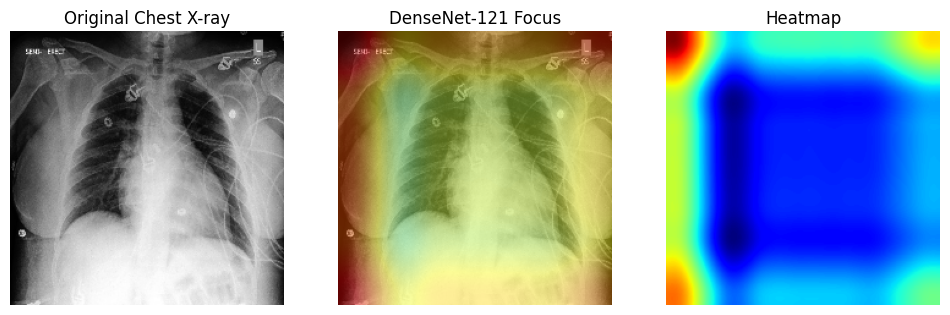

In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torchxrayvision as xrv

# =========================
# CONFIG
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# LOAD MODEL
# =========================
print("👁️ Loading DenseNet-121...")
model = xrv.models.DenseNet(weights="densenet121-res224-chex")
model = model.to(device)
model.eval()

pathologies = xrv.datasets.default_pathologies

# =========================
# PREPROCESS (🔥 FIXED)
# =========================
def preprocess(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError("❌ Image not found")

    img = cv2.resize(img, (224, 224))

    # 🔥 Correct normalization (VERY IMPORTANT)
    img = img.astype(np.float32) / 255.0
    img = (img - 0.5) / 0.5   # [-1, 1]

    img = np.expand_dims(img, axis=0)  # (1, H, W)

    return torch.tensor(img).unsqueeze(0).to(device)

# =========================
# OVERLAY FUNCTION
# =========================
def overlay_cam(image, cam, alpha=0.4):
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    return np.clip(image * (1 - alpha) + heatmap * alpha, 0, 1)

# =========================
# GRAD-CAM++
# =========================
def gradcam_plus_plus(feature_maps, grads):

    grads_power_2 = grads ** 2
    grads_power_3 = grads_power_2 * grads

    sum_grads = np.sum(feature_maps * grads_power_3, axis=(1,2), keepdims=True)

    eps = 1e-8
    alpha = grads_power_2 / (2 * grads_power_2 + sum_grads + eps)

    weights = np.sum(alpha * np.maximum(grads, 0), axis=(1,2))

    cam = np.zeros(feature_maps.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * feature_maps[i]

    cam = np.maximum(cam, 0)
    cam /= (cam.max() + 1e-8)

    return cam

# =========================
# MAIN FUNCTION
# =========================
def densenet_explain(image_path):

    input_tensor = preprocess(image_path)

    # original image for display
    raw_img = cv2.imread(image_path)
    raw_img = cv2.resize(raw_img, (224,224))
    img_array = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB) / 255.0

    model.zero_grad()

    print("🚀 Running DenseNet...")

    features = []
    grads = []

    def hook_fn(module, input, output):
        features.clear()
        grads.clear()
        features.append(output)
        output.register_hook(lambda grad: grads.append(grad))

    # 🔥 Best layer for localization
    handle = model.features.transition3.register_forward_hook(hook_fn)

    # =========================
    # FORWARD
    # =========================
    logits = model(input_tensor)
    probs = torch.sigmoid(logits)[0].detach().cpu().numpy()

    # =========================
    # PRINT OUTPUT
    # =========================
    print("\n📊 Predictions:")
    for i, p in enumerate(probs):
        print(f"{pathologies[i]:25}: {p:.3f}")

    print("\n📊 Logits:")
    for i, l in enumerate(logits[0].detach().cpu().numpy()):
        print(f"{pathologies[i]:25}: {l:.4f}")

    # =========================
    # SELECT TOP-1
    # =========================
    idx = int(np.argmax(probs))

    print("\n🔥 Final Prediction:")
    print(f"{pathologies[idx]}: {probs[idx]:.3f}")

    # =========================
    # BACKPROP
    # =========================
    model.zero_grad()
    logits[0, idx].backward()

    fmap = features[0][0].detach().cpu().numpy()
    grad = grads[0][0].detach().cpu().numpy()

    cam = gradcam_plus_plus(fmap, grad)

    # 🔥 Improve CAM
    cam = cv2.resize(cam, (224, 224), interpolation=cv2.INTER_CUBIC)
    cam = np.power(cam, 2.0)
    cam = cv2.GaussianBlur(cam, (7,7), 0)
    cam = cam / (cam.max() + 1e-8)

    # =========================
    # DISPLAY
    # =========================
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img_array)
    plt.title("Original Chest X-ray")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(overlay_cam(img_array, cam))
    plt.title("DenseNet-121 Focus")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(cam, cmap='jet')
    plt.title("Heatmap")
    plt.axis('off')

    plt.show()

    handle.remove()

# =========================
# RUN
# =========================
image_path = r"D:\Mtech_Project_Data_2\CheXpert-v1.0-small\valid\patient64549\study1\view1_frontal.jpg"

densenet_explain(image_path)

🚀 Loading ViT-B/16...
✅ Model Loaded

📊 All Predictions:

Atelectasis                   : 0.011
Cardiomegaly                  : 0.205
Consolidation                 : 0.746
Edema                         : 0.086
Enlarged Cardiomediastinum    : 0.016
Fracture                      : 0.311
Lung Lesion                   : 0.007
Lung Opacity                  : 0.009
No Finding                    : 0.050
Pleural Effusion              : 0.008
Pleural Other                 : 0.022
Pneumonia                     : 0.002
Pneumothorax                  : 0.037
Support Devices               : 0.178

🔥 Final Predictions:

Cardiomegaly: 0.205
Consolidation: 0.746
Fracture: 0.311


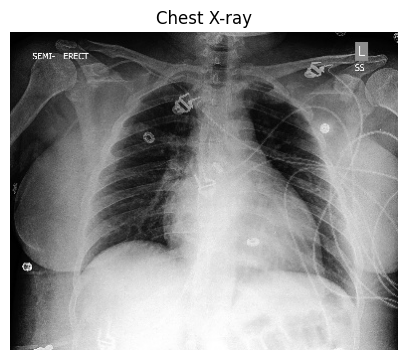

In [ ]:
import torch
import timm
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# CHEXPERT LABELS
# =========================
diseases = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema",
    "Enlarged Cardiomediastinum", "Fracture", "Lung Lesion",
    "Lung Opacity", "No Finding", "Pleural Effusion",
    "Pleural Other", "Pneumonia", "Pneumothorax", "Support Devices"
]

# =========================
# LOAD MODEL
# =========================
print("🚀 Loading ViT-B/16...")

model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=False,
    num_classes=14
)

# 🔥 LOAD CHECKPOINT CORRECTLY
checkpoint_path = r"C:\Users\ansiy\Desktop\Chexpert_web_app\checkpoints1\best_vit_model_100k.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])  # FIXED
model = model.to(device)
model.eval()

print("✅ Model Loaded")

# =========================
# PREPROCESS
# =========================
def preprocess(image_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5, 0.5, 0.5],
            std=[0.5, 0.5, 0.5]
        )
    ])

    # 🔥 IMPORTANT FIX (grayscale → RGB)
    image = Image.open(image_path).convert("RGB")

    image_tensor = transform(image).unsqueeze(0)
    return image_tensor.to(device), image


# =========================
# PREDICTION FUNCTION
# =========================
def vit_predict(image_path):

    input_tensor, original_img = preprocess(image_path)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0].cpu().numpy()

    # =========================
    # PRINT ALL PROBABILITIES
    # =========================
    print("\n📊 All Predictions:\n")
    for i, disease in enumerate(diseases):
        print(f"{disease:30s}: {probs[i]:.3f}")

    # =========================
    # SMART SELECTION
    # =========================
    threshold = 0.2

    selected = [(diseases[i], probs[i]) for i in range(len(probs)) if probs[i] > threshold]

    # If nothing passes threshold → take top-2
    if len(selected) == 0:
        print("\n⚠️ No strong disease → showing top 2\n")
        top_k = 2
        top_indices = np.argsort(probs)[-top_k:][::-1]
        selected = [(diseases[i], probs[i]) for i in top_indices]

    # =========================
    # FINAL OUTPUT
    # =========================
    print("\n🔥 Final Predictions:\n")
    for d, p in selected:
        print(f"{d}: {p:.3f}")

    # =========================
    # DISPLAY IMAGE
    # =========================
    img = cv2.imread(image_path, 0)

    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap='gray')
    plt.title("Chest X-ray")
    plt.axis('off')
    plt.show()


# =========================
# RUN
# =========================
image_path = r"D:\Mtech_Project_Data_2\CheXpert-v1.0-small\valid\patient64549\study1\view1_frontal.jpg"

vit_predict(image_path)

🚀 Running model...

📊 Predictions:
No Finding               : 0.022
Enlarged Cardiomediastinum: 0.320
Cardiomegaly             : 0.799
Lung Opacity             : 0.137
Lung Lesion              : 0.045
Edema                    : 0.566
Consolidation            : 0.023
Pneumonia                : 0.021
Atelectasis              : 0.069
Pneumothorax             : 0.009
Pleural Effusion         : 0.036
Pleural Other            : 0.003
Fracture                 : 0.241
Support Devices          : 0.171

🔥 Enlarged Cardiomediastinum | Prob: 0.320
ViT: 0.46 | CNN: 0.54


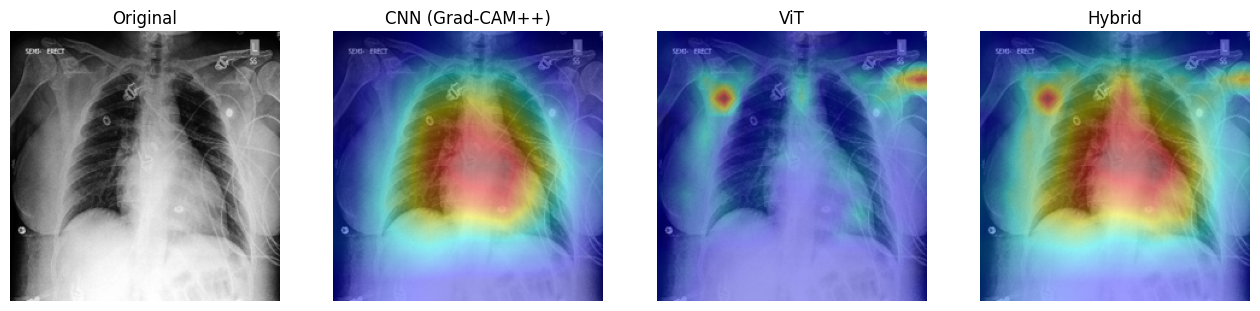


🔥 Cardiomegaly | Prob: 0.799
ViT: 0.60 | CNN: 0.40


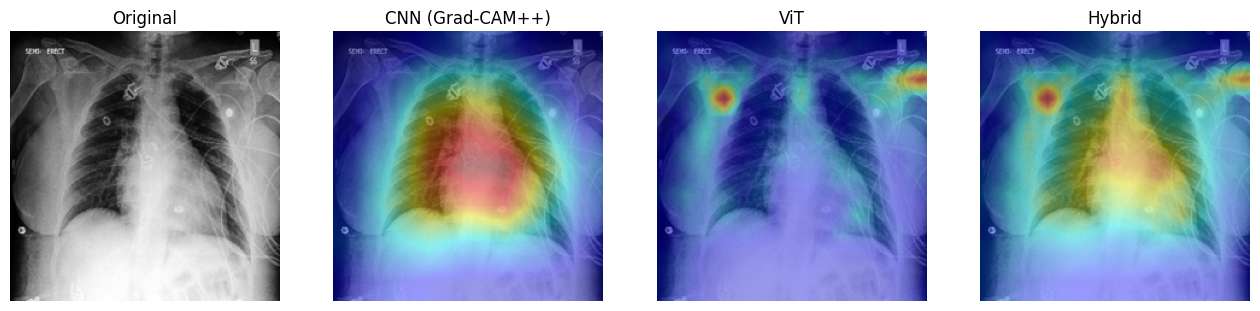


🔥 Edema | Prob: 0.566
ViT: 0.59 | CNN: 0.41


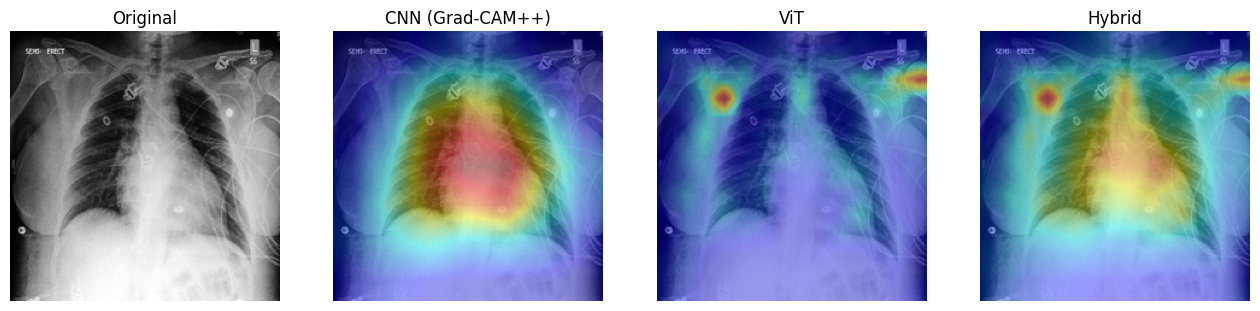

In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

THRESHOLD = 0.3

# =========================
# 🔥 OVERLAY FUNCTION
# =========================
def overlay_cam(image, cam, alpha=0.4):
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    return np.clip(image * (1 - alpha) + heatmap * alpha, 0, 1)

# =========================
# 🔥 GRAD-CAM++ (CNN)
# =========================
def gradcam_plus_plus(feature_maps, grads):

    grads_power_2 = grads ** 2
    grads_power_3 = grads_power_2 * grads

    sum_grads = np.sum(feature_maps * grads_power_3, axis=(1,2), keepdims=True)

    eps = 1e-8
    alpha = grads_power_2 / (2 * grads_power_2 + sum_grads + eps)

    weights = np.sum(alpha * np.maximum(grads, 0), axis=(1,2))

    cam = np.zeros(feature_maps.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * feature_maps[i]

    cam = np.maximum(cam, 0)
    cam /= (cam.max() + 1e-8)

    return cam

# =========================
# 🔥 PATCH VIT ATTENTION
# =========================
def patch_vit_attention(model):

    def save_attn(self, x, attn_mask=None):
        B, N, C = x.shape

        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads)
        q, k, v = qkv.permute(2, 0, 3, 1, 4)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)

        self.attn_probs = attn

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)

        return x

    for blk in model.vit.blocks:
        blk.attn.forward = save_attn.__get__(blk.attn, type(blk.attn))

# =========================
# 🔥 VIT ROLLOUT
# =========================
def compute_vit_rollout(model):

    attn_mats = []

    for blk in model.vit.blocks:
        if hasattr(blk.attn, "attn_probs") and blk.attn.attn_probs is not None:
            attn = blk.attn.attn_probs.detach().cpu()
            attn = attn.mean(dim=1)
            attn_mats.append(attn)

    if len(attn_mats) == 0:
        return np.zeros((224, 224))

    rollout = torch.eye(attn_mats[0].size(-1))

    for attn in attn_mats:
        attn = attn[0] + torch.eye(attn.size(-1))
        attn = attn / attn.sum(dim=-1, keepdim=True)
        rollout = attn @ rollout

    cam = rollout[0, 1:]

    size = int(np.sqrt(len(cam)))
    cam = cam.reshape(size, size).numpy()

    cam = cv2.resize(cam, (224, 224))
    cam = np.maximum(cam, 0)
    cam /= (cam.max() + 1e-8)

    return cam

# =========================
# 🚀 MAIN FUNCTION
# =========================
def hybrid_explain(model, pathology_list, device):

    image_path = r"D:\Mtech_Project_Data_2\CheXpert-v1.0-small\valid\patient64549\study1\view1_frontal.jpg"

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    raw_image = Image.open(image_path).convert('RGB')
    img_resized = raw_image.resize((224, 224))
    img_array = np.array(img_resized) / 255.0

    input_tensor = transform(raw_image).unsqueeze(0).to(device)

    model.eval()
    model.zero_grad()

    print("🚀 Running model...")

    # Reset attention
    for blk in model.vit.blocks:
        blk.attn.attn_probs = None

    patch_vit_attention(model)

    # CNN hook
    cnn_features = []
    cnn_grads = []

    def hook_fn(module, input, output):
        cnn_features.clear()
        cnn_grads.clear()
        cnn_features.append(output)
        output.register_hook(lambda grad: cnn_grads.append(grad))

    handle = model.cnn.features.norm5.register_forward_hook(hook_fn)

    # Forward
    logits, attention = model(input_tensor)
    probs = torch.sigmoid(logits)[0].detach().cpu().numpy()

    print("\n📊 Predictions:")
    for i, p in enumerate(probs):
        print(f"{pathology_list[i]:25}: {p:.3f}")

    # Select diseases
    selected_indices = np.where(probs > THRESHOLD)[0]

    if len(selected_indices) == 0:
        print("\n⚠️ No disease above threshold → showing top")
        selected_indices = [np.argmax(probs)]

    # ViT CAM
    cam_vit = compute_vit_rollout(model)

    # Loop
    for target_idx in selected_indices:

        model.zero_grad()
        logits[0, target_idx].backward(retain_graph=True)

        fmap = cnn_features[0][0].detach().cpu().numpy()
        grads = cnn_grads[0][0].detach().cpu().numpy()

        # 🔥 Grad-CAM++
        cam_cnn = gradcam_plus_plus(fmap, grads)
        cam_cnn = cv2.resize(cam_cnn, (224, 224))

        # 🔥 Hybrid fusion
        alpha = attention[0, target_idx].item()
        alpha = 0.2 + 0.6 * alpha

        cam_hybrid = alpha * cam_vit + (1 - alpha) * cam_cnn
        cam_hybrid /= (cam_hybrid.max() + 1e-8)

        disease = pathology_list[target_idx]

        print(f"\n🔥 {disease} | Prob: {probs[target_idx]:.3f}")
        print(f"ViT: {alpha:.2f} | CNN: {1-alpha:.2f}")

        # Display
        plt.figure(figsize=(16,4))

        plt.subplot(1,4,1)
        plt.imshow(img_resized)
        plt.title("Original")
        plt.axis('off')

        plt.subplot(1,4,2)
        plt.imshow(overlay_cam(img_array, cam_cnn))
        plt.title("CNN (Grad-CAM++)")
        plt.axis('off')

        plt.subplot(1,4,3)
        plt.imshow(overlay_cam(img_array, cam_vit))
        plt.title("ViT")
        plt.axis('off')

        plt.subplot(1,4,4)
        plt.imshow(overlay_cam(img_array, cam_hybrid))
        plt.title("Hybrid")
        plt.axis('off')

        plt.show()

    handle.remove()

# =========================
# 🚀 RUN
# =========================
hybrid_explain(
    hybrid_model,
    chexpert_pathologies,
    device
)    

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm
import timm
import torchxrayvision as xrv
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, log_loss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# PATHS
# =========================
vit_path = r"C:\Users\ansiy\Desktop\Chexpert_web_app\checkpoints1\best_vit_model_100k.pth"
cnn_path = r"C:\Users\ansiy\Desktop\Chexpert_web_app\densenet_checkpoints\best_densenet121.pth"
hybrid_path = r"C:\Users\ansiy\Desktop\Chexpert_web_app\best_hybrid_model_v2.pth"

# =========================
# LOAD VIT
# =========================
print("🧠 Loading ViT...")
vit_model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=14)

vit_ckpt = torch.load(vit_path, map_location=device)
vit_model.load_state_dict(vit_ckpt['model_state_dict'] if 'model_state_dict' in vit_ckpt else vit_ckpt)

vit_model = vit_model.to(device)
vit_model.eval()

# =========================
# LOAD DENSENET (FIXED)
# =========================
print("👁️ Loading DenseNet...")

cnn_model = xrv.models.DenseNet(weights=None)

# 🔥 IMPORTANT FIX (14 classes)
cnn_model.classifier = nn.Linear(1024, 14)

cnn_ckpt = torch.load(cnn_path, map_location=device)
cnn_model.load_state_dict(cnn_ckpt['model_state_dict'] if 'model_state_dict' in cnn_ckpt else cnn_ckpt)

cnn_model = cnn_model.to(device)
cnn_model.eval()

# =========================
# LOAD HYBRID
# =========================
print("⚖️ Loading Hybrid...")

hybrid_model = HybridViTDenseNet(num_classes=14, device=device).to(device)

hybrid_ckpt = torch.load(hybrid_path, map_location=device)
hybrid_model.load_state_dict(hybrid_ckpt['model_state_dict'])

hybrid_model.eval()

# =========================
# STORAGE
# =========================
gt_all, vit_all, cnn_all, hybrid_all = [], [], [], []

THRESHOLD = 0.2

print("\n🚀 Running evaluation...")

with torch.no_grad():
    for images, labels in tqdm(hybrid_val_loader):

        images = images.to(device)
        labels = labels.cpu().numpy()

        # -------- ViT --------
        vit_logits = vit_model(images)
        vit_probs = torch.sigmoid(vit_logits).cpu().numpy()

        # -------- CNN --------
        x_gray = images.mean(dim=1, keepdim=True)
        cnn_logits = cnn_model(x_gray)
        cnn_probs = torch.sigmoid(cnn_logits).cpu().numpy()

        # -------- Hybrid --------
        hybrid_logits, _ = hybrid_model(images)
        hybrid_probs = torch.sigmoid(hybrid_logits).cpu().numpy()

        gt_all.append(labels)
        vit_all.append(vit_probs)
        cnn_all.append(cnn_probs)
        hybrid_all.append(hybrid_probs)

# =========================
# CONCAT
# =========================
gt_all = np.vstack(gt_all)
vit_all = np.vstack(vit_all)
cnn_all = np.vstack(cnn_all)
hybrid_all = np.vstack(hybrid_all)

# =========================
# BINARY
# =========================
vit_bin = (vit_all > THRESHOLD).astype(int)
cnn_bin = (cnn_all > THRESHOLD).astype(int)
hybrid_bin = (hybrid_all > THRESHOLD).astype(int)

# =========================
# METRICS FUNCTION
# =========================
def compute_metrics(y_true, y_pred_prob):

    aucs = []
    for i in range(y_true.shape[1]):
        if len(np.unique(y_true[:, i])) > 1:
            aucs.append(roc_auc_score(y_true[:, i], y_pred_prob[:, i]))

    mean_auc = np.mean(aucs)

    y_pred_bin = (y_pred_prob > THRESHOLD).astype(int)

    f1 = f1_score(y_true, y_pred_bin, average='macro')
    precision = precision_score(y_true, y_pred_bin, average='macro')
    recall = recall_score(y_true, y_pred_bin, average='macro')
    logloss = log_loss(y_true.flatten(), y_pred_prob.flatten())

    return mean_auc, f1, precision, recall, logloss

# =========================
# COMPUTE METRICS
# =========================
print("\n📊 OVERALL METRICS")

vit_metrics = compute_metrics(gt_all, vit_all)
cnn_metrics = compute_metrics(gt_all, cnn_all)
hyb_metrics = compute_metrics(gt_all, hybrid_all)

print("ViT     :", vit_metrics)
print("DenseNet:", cnn_metrics)
print("Hybrid  :", hyb_metrics)

# =========================
# DISEASE-WISE RECALL
# =========================
chexpert_pathologies = [
    'No Finding','Enlarged Cardiomediastinum','Cardiomegaly',
    'Lung Opacity','Lung Lesion','Edema','Consolidation',
    'Pneumonia','Atelectasis','Pneumothorax',
    'Pleural Effusion','Pleural Other','Fracture','Support Devices'
]

print("\n🧠 DISEASE-WISE DETECTION (Recall)")
print("-"*90)
print(f"{'Disease':25} | {'Total+':6} | {'ViT':6} | {'CNN':6} | {'Hybrid':6}")
print("-"*90)

for i, disease in enumerate(chexpert_pathologies):

    y_true = gt_all[:, i]
    total_pos = np.sum(y_true == 1)

    if total_pos == 0:
        continue

    tp_vit = np.sum((y_true == 1) & (vit_bin[:, i] == 1))
    tp_cnn = np.sum((y_true == 1) & (cnn_bin[:, i] == 1))
    tp_hyb = np.sum((y_true == 1) & (hybrid_bin[:, i] == 1))

    print(f"{disease:25} | {total_pos:<6} | {tp_vit/total_pos:.3f} | {tp_cnn/total_pos:.3f} | {tp_hyb/total_pos:.3f}")
    

🧠 Loading ViT...
👁️ Loading DenseNet...
⚖️ Loading Hybrid...
🧠 Loading trained ViT...
👁️ Loading DenseNet...
❄️ Freezing backbones...
🔓 Selective unfreezing...
🎨 Projection layers...
⚖️ Attention-based Fusion...

🚀 Running evaluation...


100%|██████████| 313/313 [08:38<00:00,  1.66s/it]



📊 OVERALL METRICS
ViT     : (0.8201963584053227, 0.44749345361214454, 0.4047427739145544, 0.5419064323388847, 0.28203926591714107)
DenseNet: (0.7540770599852472, 0.34349098299304653, 0.33370922499082806, 0.4266906626237787, 0.31839136402401946)
Hybrid  : (0.8100070262532386, 0.42260435728995244, 0.32817718623026576, 0.6675991618622409, 0.30503176143536986)

🧠 DISEASE-WISE DETECTION (Recall)
------------------------------------------------------------------------------------------
Disease                   | Total+ | ViT    | CNN    | Hybrid
------------------------------------------------------------------------------------------
No Finding                | 343    | 0.563 | 0.402 | 0.627
Enlarged Cardiomediastinum | 676    | 0.167 | 0.058 | 0.212
Cardiomegaly              | 1342   | 0.725 | 0.653 | 0.820
Lung Opacity              | 5038   | 0.969 | 0.986 | 0.991
Lung Lesion               | 610    | 0.315 | 0.151 | 0.656
Edema                     | 2329   | 0.866 | 0.810 | 0.950
Consol

🧠 Loading ViT...
👁️ Loading DenseNet...
⚖️ Loading Hybrid...
🧠 Loading trained ViT...
👁️ Loading DenseNet...
❄️ Freezing backbones...
🔓 Selective unfreezing...
🎨 Projection layers...
⚖️ Attention-based Fusion...
📂 Indexing all images...
✅ Total images found: 112120
Total batches: 7008

🚀 Running NIH FULL evaluation...


  0%|          | 0/7008 [00:00<?, ?it/s]

🔥 First batch running...


100%|██████████| 7008/7008 [35:39<00:00,  3.28it/s]



📊 NIH OVERALL METRICS
ViT     : (0.7817449678381597, 0.2215428491405271, 0.15528008232951981, 0.48927113496261426, 0.2000264072494976)
DenseNet: (0.731781678317973, 0.1422994490517892, 0.13578599806630767, 0.39296481894190144, 0.21942902516164645)
Hybrid  : (0.7698878058696346, 0.2084675089447859, 0.14247778496651747, 0.5917448517033458, 0.24677407317777553)

🧠 NIH DISEASE-WISE RECALL
------------------------------------------------------------------------------------------
Disease                   | Total+ | ViT    | CNN    | Hybrid
------------------------------------------------------------------------------------------
Atelectasis               | 11535  | 0.531 | 0.296 | 0.659
Cardiomegaly              | 2772   | 0.653 | 0.694 | 0.694
Effusion                  | 13307  | 0.833 | 0.840 | 0.900
Edema                     | 2303   | 0.771 | 0.839 | 0.881
Consolidation             | 4667   | 0.128 | 0.009 | 0.499
Pneumonia                 | 1353   | 0.068 | 0.007 | 0.231
Pneumothorax 

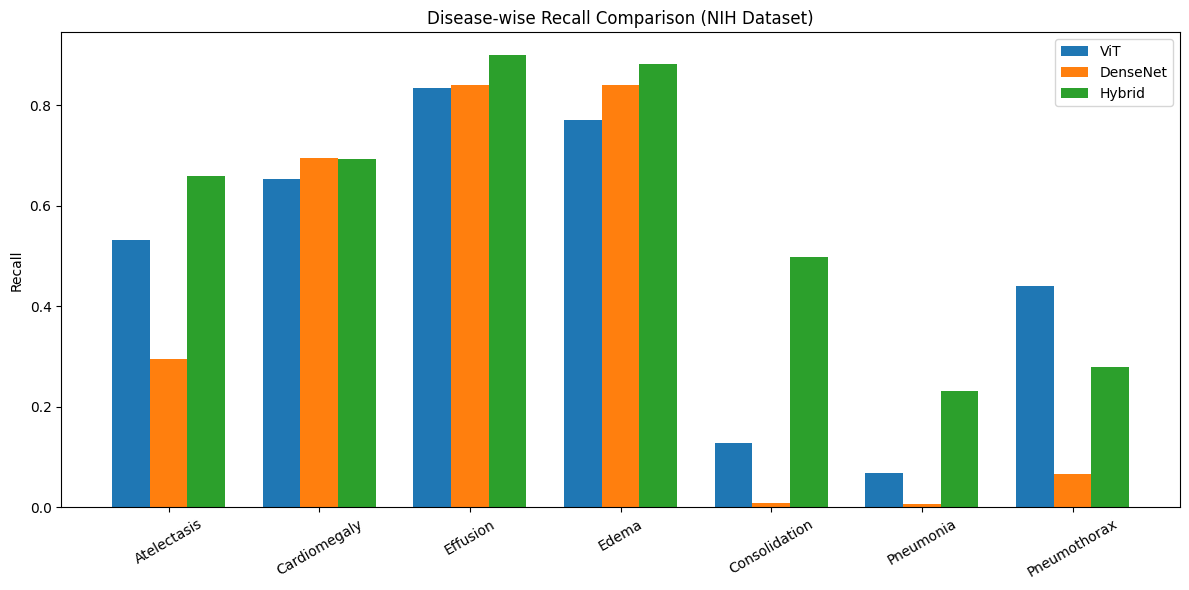

✅ Saved: nih_disease_wise_recall.png


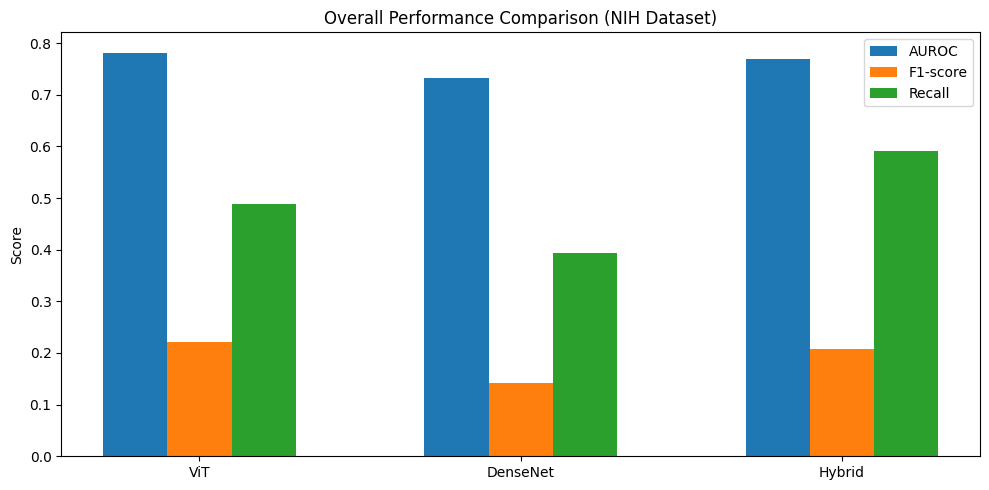

✅ Saved: nih_overall_metrics.png

📊 Average Recall:
ViT     : 0.48927113496261426
DenseNet: 0.39296481894190144
Hybrid  : 0.5917448517033458


In [18]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import timm
import torchxrayvision as xrv
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, log_loss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
THRESHOLD = 0.2

# =========================
# PATHS
# =========================
vit_path = r"C:\Users\ansiy\Desktop\Chexpert_web_app\checkpoints1\best_vit_model_100k.pth"
cnn_path = r"C:\Users\ansiy\Desktop\Chexpert_web_app\densenet_checkpoints\best_densenet121.pth"
hybrid_path = r"C:\Users\ansiy\Desktop\Chexpert_web_app\best_hybrid_model_v2.pth"

csv_path = r"C:\Users\ansiy\Downloads\NIH\Data_Entry_2017.csv"
img_dir  = r"C:\Users\ansiy\Downloads\NIH\images-224"

# =========================
# LOAD MODELS
# =========================
print("🧠 Loading ViT...")
vit_model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=14)
vit_model.load_state_dict(torch.load(vit_path, map_location=device)['model_state_dict'])
vit_model = vit_model.to(device).eval()

print("👁️ Loading DenseNet...")
cnn_model = xrv.models.DenseNet(weights=None)
cnn_model.classifier = nn.Linear(1024, 14)
cnn_model.load_state_dict(torch.load(cnn_path, map_location=device)['model_state_dict'])
cnn_model = cnn_model.to(device).eval()

print("⚖️ Loading Hybrid...")
hybrid_model = HybridViTDenseNet(num_classes=14, device=device).to(device)
hybrid_model.load_state_dict(torch.load(hybrid_path, map_location=device)['model_state_dict'])
hybrid_model.eval()

# =========================
# NIH CLASSES
# =========================
nih_classes = [
    'Atelectasis','Cardiomegaly','Effusion',
    'Edema','Consolidation','Pneumonia','Pneumothorax'
]

cx_index_map = {
    'Atelectasis': 8,
    'Cardiomegaly': 2,
    'Effusion': 10,
    'Edema': 5,
    'Consolidation': 6,
    'Pneumonia': 7,
    'Pneumothorax': 9
}

# =========================
# BUILD IMAGE PATH MAP (🔥 IMPORTANT FIX)
# =========================
print("📂 Indexing all images...")

image_paths = {}
for root, _, files in os.walk(img_dir):
    for f in files:
        image_paths[f] = os.path.join(root, f)

print("✅ Total images found:", len(image_paths))

# =========================
# DATASET
# =========================
class NIHFullDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_name = row['Image Index']
        img_path = image_paths.get(img_name, None)

        if img_path is None:
            return None

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return None

        img = cv2.resize(img, (224,224)).astype(np.float32) / 255.0
        img = np.stack([img, img, img], axis=0)

        mean = np.array([0.485, 0.456, 0.406]).reshape(3,1,1)
        std = np.array([0.229, 0.224, 0.225]).reshape(3,1,1)

        img = (img - mean) / std

        labels = np.zeros(len(nih_classes))
        findings = str(row["Finding Labels"]).split('|')

        for i, d in enumerate(nih_classes):
            if d in findings:
                labels[i] = 1

        return torch.tensor(img, dtype=torch.float32), torch.tensor(labels, dtype=torch.float32)

# =========================
# COLLATE (skip None samples)
# =========================
def collate_fn(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None
    return torch.utils.data.dataloader.default_collate(batch)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(csv_path)

dataset = NIHFullDataset(df)

loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,   # 🔥 Windows fix
    collate_fn=collate_fn
)

print("Total batches:", len(loader))

# =========================
# EVALUATION
# =========================
gt_all, vit_all, cnn_all, hybrid_all = [], [], [], []

print("\n🚀 Running NIH FULL evaluation...")

with torch.no_grad():
    for i, batch in enumerate(tqdm(loader)):

        if batch is None:
            continue

        images, labels = batch
        images = images.to(device)
        labels = labels.numpy()

        if i == 0:
            print("🔥 First batch running...")

        vit_probs = torch.sigmoid(vit_model(images)).cpu().numpy()
        cnn_probs = torch.sigmoid(cnn_model(images.mean(dim=1, keepdim=True))).cpu().numpy()
        hybrid_probs = torch.sigmoid(hybrid_model(images)[0]).cpu().numpy()

        idxs = [cx_index_map[c] for c in nih_classes]

        gt_all.append(labels)
        vit_all.append(vit_probs[:, idxs])
        cnn_all.append(cnn_probs[:, idxs])
        hybrid_all.append(hybrid_probs[:, idxs])

# =========================
# CONCAT
# =========================
gt_all = np.vstack(gt_all)
vit_all = np.vstack(vit_all)
cnn_all = np.vstack(cnn_all)
hybrid_all = np.vstack(hybrid_all)

# =========================
# METRICS
# =========================
def compute_metrics(y_true, y_pred_prob):

    aucs = []
    for i in range(y_true.shape[1]):
        if len(np.unique(y_true[:, i])) > 1:
            aucs.append(roc_auc_score(y_true[:, i], y_pred_prob[:, i]))

    mean_auc = np.mean(aucs)

    y_pred_bin = (y_pred_prob > THRESHOLD).astype(int)

    return (
        mean_auc,
        f1_score(y_true, y_pred_bin, average='macro'),
        precision_score(y_true, y_pred_bin, average='macro'),
        recall_score(y_true, y_pred_bin, average='macro'),
        log_loss(y_true.flatten(), y_pred_prob.flatten())
    )

# =========================
# RESULTS
# =========================
print("\n📊 NIH OVERALL METRICS")
print("ViT     :", compute_metrics(gt_all, vit_all))
print("DenseNet:", compute_metrics(gt_all, cnn_all))
print("Hybrid  :", compute_metrics(gt_all, hybrid_all))

# =========================
# DISEASE-WISE RECALL
# =========================
print("\n🧠 NIH DISEASE-WISE RECALL")
print("-"*90)
print(f"{'Disease':25} | {'Total+':6} | {'ViT':6} | {'CNN':6} | {'Hybrid':6}")
print("-"*90)

vit_bin = (vit_all > THRESHOLD).astype(int)
cnn_bin = (cnn_all > THRESHOLD).astype(int)
hyb_bin = (hybrid_all > THRESHOLD).astype(int)

for i, disease in enumerate(nih_classes):

    y_true = gt_all[:, i]
    total_pos = np.sum(y_true == 1)

    if total_pos == 0:
        continue

    tp_vit = np.sum((y_true == 1) & (vit_bin[:, i] == 1))
    tp_cnn = np.sum((y_true == 1) & (cnn_bin[:, i] == 1))
    tp_hyb = np.sum((y_true == 1) & (hyb_bin[:, i] == 1))

    print(f"{disease:25} | {total_pos:<6} | {tp_vit/total_pos:.3f} | {tp_cnn/total_pos:.3f} | {tp_hyb/total_pos:.3f}")

# =========================
# 📊 STORE VALUES FOR GRAPH
# =========================
import matplotlib.pyplot as plt

diseases = []
vit_scores = []
cnn_scores = []
hyb_scores = []

for i, disease in enumerate(nih_classes):

    y_true = gt_all[:, i]
    total_pos = np.sum(y_true == 1)

    if total_pos == 0:
        continue

    tp_vit = np.sum((y_true == 1) & (vit_bin[:, i] == 1))
    tp_cnn = np.sum((y_true == 1) & (cnn_bin[:, i] == 1))
    tp_hyb = np.sum((y_true == 1) & (hyb_bin[:, i] == 1))

    diseases.append(disease)
    vit_scores.append(tp_vit / total_pos)
    cnn_scores.append(tp_cnn / total_pos)
    hyb_scores.append(tp_hyb / total_pos)

# =========================
# 📊 GRAPH 1: DISEASE-WISE RECALL
# =========================
x = np.arange(len(diseases))

plt.figure(figsize=(12,6))
plt.bar(x - 0.25, vit_scores, width=0.25, label='ViT')
plt.bar(x, cnn_scores, width=0.25, label='DenseNet')
plt.bar(x + 0.25, hyb_scores, width=0.25, label='Hybrid')

plt.xticks(x, diseases, rotation=30)
plt.ylabel("Recall")
plt.title("Disease-wise Recall Comparison (NIH Dataset)")
plt.legend()

plt.tight_layout()
plt.savefig("nih_disease_wise_recall.png")
plt.show()

print("✅ Saved: nih_disease_wise_recall.png")

# =========================
# 📊 GRAPH 2: OVERALL METRICS
# =========================
vit_m = compute_metrics(gt_all, vit_all)
cnn_m = compute_metrics(gt_all, cnn_all)
hyb_m = compute_metrics(gt_all, hybrid_all)

models = ['ViT', 'DenseNet', 'Hybrid']

auroc = [vit_m[0], cnn_m[0], hyb_m[0]]
f1 = [vit_m[1], cnn_m[1], hyb_m[1]]
recall_vals = [vit_m[3], cnn_m[3], hyb_m[3]]

x = np.arange(len(models))

plt.figure(figsize=(10,5))
plt.bar(x - 0.2, auroc, width=0.2, label='AUROC')
plt.bar(x, f1, width=0.2, label='F1-score')
plt.bar(x + 0.2, recall_vals, width=0.2, label='Recall')

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Overall Performance Comparison (NIH Dataset)")
plt.legend()

plt.tight_layout()
plt.savefig("nih_overall_metrics.png")
plt.show()

print("✅ Saved: nih_overall_metrics.png")

# =========================
# 📊 BONUS: PRINT AVG RECALL
# =========================
print("\n📊 Average Recall:")
print("ViT     :", np.mean(vit_scores))
print("DenseNet:", np.mean(cnn_scores))
print("Hybrid  :", np.mean(hyb_scores))    


 FINAL PREDICTIONS
ViT     : ['Lung Opacity (0.60)', 'Pleural Effusion (0.85)', 'Support Devices (0.70)']
DenseNet: ['Lung Opacity (0.56)', 'Pleural Effusion (0.69)', 'Support Devices (0.43)']
Hybrid  : ['Cardiomegaly (0.56)', 'Lung Opacity (0.70)', 'Edema (0.25)', 'Pneumothorax (0.26)', 'Pleural Effusion (0.86)', 'Support Devices (0.56)']


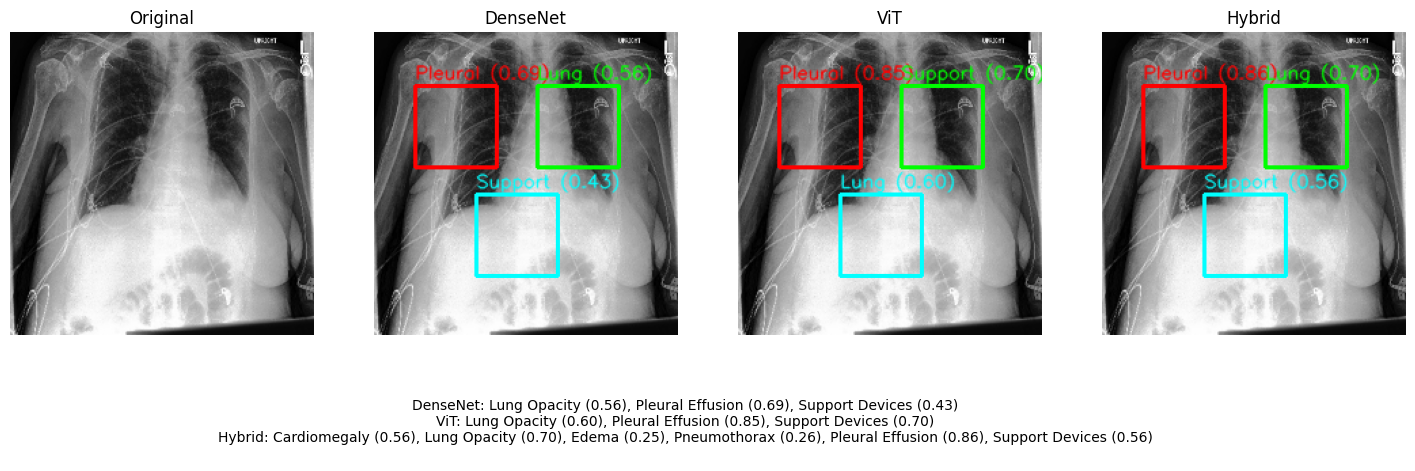


✅ Saved as comparison.png


In [99]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

THRESHOLD = 0.2

# =========================
# CLASS NAMES
# =========================
disease_names = [
    'No Finding','Enlarged Cardiomediastinum','Cardiomegaly',
    'Lung Opacity','Lung Lesion','Edema','Consolidation',
    'Pneumonia','Atelectasis','Pneumothorax',
    'Pleural Effusion','Pleural Other','Fracture','Support Devices'
]

# =========================
# PREPROCESS IMAGE
# =========================
def preprocess_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError("❌ Image not found")

    img = cv2.resize(img, (224,224)).astype(np.float32) / 255.0

    img_3 = np.stack([img, img, img], axis=0)

    mean = np.array([0.485, 0.456, 0.406]).reshape(3,1,1)
    std = np.array([0.229, 0.224, 0.225]).reshape(3,1,1)

    img_3 = (img_3 - mean) / std

    return torch.tensor(img_3, dtype=torch.float32).unsqueeze(0), img

# =========================
# LABELS
# =========================
def get_labels(probs):
    labels = []
    for i, p in enumerate(probs):
        if p > THRESHOLD:
            labels.append(f"{disease_names[i]} ({p:.2f})")
    return labels if labels else ["None"]

# =========================
# IMPROVED HEATMAP (VISIBLE)
# =========================
 # =========================
# DRAW CLEAN LABELED BOXES
# =========================
def draw_topk_boxes(img, probs, top_k=3):

    img = np.uint8(img * 255)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    # Top-K diseases
    indices = np.argsort(probs)[::-1][:top_k]

    # Fixed positions (clean layout)
    positions = [
        (30, 40),
        (120, 40),
        (75, 120)
    ]

    colors = [
        (255, 0, 0),     # Red
        (0, 255, 0),     # Green
        (0, 255, 255)    # Yellow
    ]

    for i, idx in enumerate(indices):
        prob = probs[idx]
        label = disease_names[idx]

        x, y = positions[i]
        color = colors[i]

        # Draw box
        cv2.rectangle(img, (x, y), (x+60, y+60), color, 2)

        # Short label (important)
        short_label = label.split()[0]

        text = f"{short_label} ({prob:.2f})"

        cv2.putText(
            img,
            text,
            (x, y - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            color,
            1,
            cv2.LINE_AA
        )

    return img

# =========================
# MAIN FUNCTION
# =========================
def visualize_manual(models, img_path, save_path="comparison.png"):

    vit_model, cnn_model, hybrid_model = models

    vit_model.eval()
    cnn_model.eval()
    hybrid_model.eval()

    image_tensor, original_img = preprocess_image(img_path)
    image_tensor = image_tensor.to(device)

    with torch.no_grad():

        # -------- ViT --------
        vit_probs = torch.sigmoid(vit_model(image_tensor)).cpu().numpy()[0]

        # -------- DenseNet --------
        x_gray = image_tensor.mean(dim=1, keepdim=True)
        cnn_probs = torch.sigmoid(cnn_model(x_gray)).cpu().numpy()[0]

        # -------- Hybrid --------
        hybrid_logits, attention = hybrid_model(image_tensor)
        hybrid_probs = torch.sigmoid(hybrid_logits).cpu().numpy()[0]

    # =========================
    # LABELS
    # =========================
    vit_labels = get_labels(vit_probs)
    cnn_labels = get_labels(cnn_probs)
    hyb_labels = get_labels(hybrid_probs)

    print("\n FINAL PREDICTIONS")
    print("ViT     :", vit_labels)
    print("DenseNet:", cnn_labels)
    print("Hybrid  :", hyb_labels)

    # =========================
    # HEATMAPS
    # =========================
    vit_map = draw_topk_boxes(original_img, vit_probs)
    cnn_map = draw_topk_boxes(original_img, cnn_probs)
    hyb_map = draw_topk_boxes(original_img, hybrid_probs)


    # =========================
    # PLOT
    # =========================
    fig, axes = plt.subplots(1, 4, figsize=(18,5))

    axes[0].imshow(original_img, cmap='gray')
    axes[0].set_title("Original")

    axes[1].imshow(cnn_map)
    axes[1].set_title("DenseNet")

    axes[2].imshow(vit_map)
    axes[2].set_title("ViT")

    axes[3].imshow(hyb_map)
    axes[3].set_title("Hybrid")

    for ax in axes:
        ax.axis("off")

    # =========================
    # TEXT BELOW
    # =========================
    text = f"""
DenseNet: {', '.join(cnn_labels)}
ViT: {', '.join(vit_labels)}
Hybrid: {', '.join(hyb_labels)}
"""

    plt.figtext(0.5, -0.05, text, wrap=True, ha='center', fontsize=10)

    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    print(f"\n✅ Saved as {save_path}")
img_path = r"D:\Mtech_Project_Data_2\CheXpert-v1.0-small\valid\patient64644\study1\view1_frontal.jpg"
visualize_manual(
    models=(vit_model, cnn_model, hybrid_model),
    img_path=img_path
)

In [104]:
import pandas as pd
import numpy as np

# =========================
# PATH
# =========================
csv_path = r"C:\Users\ansiy\Downloads\NIH\Data_Entry_2017.csv"

df = pd.read_csv(csv_path)

# =========================
# SPLIT DATA
# =========================
disease_df = df[~df["Finding Labels"].str.contains("No Finding")]
nofinding_df = df[df["Finding Labels"] == "No Finding"]

print("Total disease images:", len(disease_df))
print("Total No Finding:", len(nofinding_df))

# =========================
# SAMPLE STRATEGY
# =========================
TOTAL_TARGET = 40000

# Keep more disease images
disease_target = int(TOTAL_TARGET * 0.7)   # 70%
nofinding_target = int(TOTAL_TARGET * 0.3) # 30%

# Sample
disease_sample = disease_df.sample(n=min(disease_target, len(disease_df)), random_state=42)
nofinding_sample = nofinding_df.sample(n=nofinding_target, random_state=42)

# =========================
# COMBINE
# =========================
subset_df = pd.concat([disease_sample, nofinding_sample])

# Shuffle
subset_df = subset_df.sample(frac=1, random_state=42).reset_index(drop=True)

# =========================
# SAVE
# =========================
save_path = r"C:\Users\ansiy\Downloads\NIH\nih_40k_balanced.csv"
subset_df.to_csv(save_path, index=False)

print("✅ Saved subset:", save_path)
print("Total subset:", len(subset_df))

Total disease images: 51708
Total No Finding: 60412
✅ Saved subset: C:\Users\ansiy\Downloads\NIH\nih_40k_balanced.csv
Total subset: 40000
